In [109]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os

In [110]:
# pip install kagglehub

In [77]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sriharshaeedala/airline-delay")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\naufi\.cache\kagglehub\datasets\sriharshaeedala\airline-delay\versions\1


In [78]:
file_path = os.path.join(path, "Airline_Delay_Cause.csv")
df = pd.read_csv(file_path)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  object 
 3   carrier_name         171666 non-null  object 
 4   airport              171666 non-null  object 
 5   airport_name         171666 non-null  object 
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 15  arr_delay        

In [79]:
Col = df.columns.drop(['year','month'])
df[Col].describe().round(2)

,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,171426.00,171223.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00,171426.00
mean,362.53,66.43,20.80,2.25,19.38,0.16,23.77,7.53,0.86,4239.49,1437.19,222.56,920.65,7.38,1651.70
std,992.89,179.54,50.32,7.31,61.68,0.72,72.39,43.65,3.77,12618.57,4215.68,821.09,3423.51,41.78,5221.88
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50.00,6.00,2.16,0.00,1.00,0.00,1.23,0.00,0.00,335.00,110.00,0.00,34.00,0.00,65.00
50%,100.00,17.00,6.40,0.40,3.91,0.00,5.00,1.00,0.00,1018.00,375.00,18.00,146.00,0.00,320.00
75%,250.00,47.00,17.26,1.86,11.71,0.00,15.26,4.00,1.00,2884.00,1109.00,146.00,477.00,0.00,1070.00
max,21977.00,4176.00,1293.91,266.42,1884.42,58.69,2069.07,4951.00,197.00,438783.00,196944.00,31960.00,112018.00,3760.00,227959.00


In [80]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


# Dataset

This dataset provides detailed information on flight arrivals and delays for U.S. airports, categorized by carriers from 2013 to 2023.
- `year`: The year of the data.
- `month`: The month of the data.
- `carrier`: Carrier code.
- `carrier_name`: Carrier name.
- `airport`: Airport code.
- `arr_flights`: Number of arriving flights.
- `arr_del15`: Number of flights delayed by 15 minutes or more.
- `carrier_ct`: Carrier count (delay due to the carrier).
- `weather_ct`: Weather count (delay due to weather).
- `nas_ct`: NAS (National Airspace System) count (delay due to the NAS).
- `security_ct`: Security count (delay due to security).
- `late_aircraft_ct`: Late aircraft count (delay due to late aircraft arrival).
- `arr_cancelled`: Number of flights canceled.
- `arr_diverted`: Number of flights diverted.
- `arr_delay`: Total arrival delay in minutes.
- `carrier_delay`: Delay in minutes attributed to the carrier.
- `weather_delay`: Delay in minutes attributed to weather.
- `nas_delay`: Delay in minutes attributed to the NAS.
- `security_delay`: Delay in minutes attributed to security.
- `late_aircraft_delay`: Delay in minutes attributed to late aircraft arrival.



# Data Cleaning

In [81]:
# No duplicates
df.duplicated().sum()

np.int64(0)

In [82]:
print(df.isna().sum())

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64


In [83]:
# We drop the Null entries in the `arr_flights` column.
rows_before_cleaning = df.shape[0]
df = df.dropna(subset=['arr_flights']).reset_index(drop=True)
rows_after_cleaning = df.shape[0]
print(f'Rows removed: {rows_before_cleaning - rows_after_cleaning}\n')
print('='*40)
print(df.isna().sum())

Rows removed: 240

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights              0
arr_del15              203
carrier_ct               0
weather_ct               0
nas_ct                   0
security_ct              0
late_aircraft_ct         0
arr_cancelled            0
arr_diverted             0
arr_delay                0
carrier_delay            0
weather_delay            0
nas_delay                0
security_delay           0
late_aircraft_delay      0
dtype: int64


In [84]:
# We check the Null entries in `arr_del15`
# df.columns
# arr_del15_columns = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
# print(df[df['arr_del15'].isna()][arr_del15_columns].sum())
# This implies it is reasonable to fill the Null values in the `arr_del15` with zero.
df = df.fillna(0)
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [85]:
df.dtypes

year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object

In [86]:
# We check that `arr_del15` is the sum of the columns listed in `arr_del15_columns`.
arr_del15_columns = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
arr_delay_columns = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
df[arr_del15_columns] = np.ceil(df[arr_del15_columns])
df['arr_del15'] = df[arr_del15_columns].sum(axis=1)
df['arr_delay'] = df[arr_delay_columns].sum(axis=1)
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,15.0,3.0,2.0,...,0.0,6.0,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,12.0,2.0,1.0,...,0.0,8.0,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,12.0,3.0,2.0,...,0.0,5.0,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,14.0,4.0,3.0,...,0.0,2.0,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,23.0,8.0,0.0,...,0.0,12.0,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [87]:
carrier_code_duplicates = df.groupby('carrier', as_index=False)['carrier_name'].agg(
        carrier_name = lambda x: x.unique(),
        count = lambda x: x.nunique()
    )
carrier_code_duplicates = carrier_code_duplicates[carrier_code_duplicates['count'] > 1]
for _, row in carrier_code_duplicates.iterrows():
    print(f"Code: {row['carrier']} -> Names: {row['carrier_name']}")

# From Google, we find that Envoy Air operates under American Eagle. Same is true for Expret Airlines LLC. 
# But since they belong to different company'set, we will keep them as separate entries. 
# We drop this column since it is redundant.

df = df.drop(columns=['carrier'])
df.head()

Code: EV -> Names: ['ExpressJet Airlines LLC' 'ExpressJet Airlines Inc.']
Code: MQ -> Names: ['Envoy Air' 'American Eagle Airlines Inc.']


,year,month,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,15.0,3.0,2.0,4.0,0.0,6.0,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,12.0,2.0,1.0,1.0,0.0,8.0,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,12.0,3.0,2.0,2.0,0.0,5.0,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,14.0,4.0,3.0,5.0,0.0,2.0,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,23.0,8.0,0.0,3.0,0.0,12.0,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [88]:
airport_name_duplicates = df.groupby('airport_name', as_index=False)['airport'].agg(
        airport_c = lambda x: x.unique(),
        count = lambda x: x.nunique()
    )
airport_name_duplicates = airport_name_duplicates[airport_name_duplicates['count'] > 1]
for _, row in airport_name_duplicates.iterrows():
    print(f"Airport Name: {row['airport_name']} -> Codes: {row['airport']}")

airport_code_duplicates = df.groupby('airport', as_index=False)['airport_name'].agg(
        airport_name = lambda x: x.unique(),
        count = lambda x: x.nunique()
    )
airport_code_duplicates = airport_code_duplicates[airport_code_duplicates['count'] > 1]
for _, row in airport_code_duplicates.iterrows():
    print(f"Airport Code: {row['airport']} -> Airport Name: {row['airport_name']}")

# We find that every airport_name corresponds to a unique airport code. However, some airport names are repeated for different airport codes.
# From Google, we find that the same airport code can correspond to different airport with different name.
# So, we keep airport_name and drop airport code since it is redundant.

df = df.drop(columns=['airport'])
df.head()


Airport Code: BFM -> Airport Name: ['Mobile, AL: Mobile Downtown' 'Mobile, AL: Mobile International']
Airport Code: BLV -> Airport Name: ['Belleville, IL: Scott AFB MidAmerica St Louis'
 'Belleville, IL: Scott AFB/MidAmerica']
Airport Code: CNY -> Airport Name: ['Moab, UT: Canyonlands Regional' 'Moab, UT: Canyonlands Field']
Airport Code: CRW -> Airport Name: ['Charleston/Dunbar, WV: West Virginia International Yeager'
 'Charleston/Dunbar, WV: Yeager']
Airport Code: GCC -> Airport Name: ['Gillette, WY: Northeast Wyoming Regional'
 'Gillette, WY: Gillette Campbell County']
Airport Code: HYA -> Airport Name: ['Hyannis, MA: Cape Cod Gateway'
 'Hyannis, MA: Barnstable Municipal-Boardman/Polando Field']
Airport Code: ITH -> Airport Name: ['Ithaca/Cortland, NY: Ithaca Tompkins International'
 'Ithaca/Cortland, NY: Ithaca Tompkins Regional']
Airport Code: LAS -> Airport Name: ['Las Vegas, NV: Harry Reid International'
 'Las Vegas, NV: McCarran International']
Airport Code: MFE -> Airport Name

,year,month,carrier_name,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,Endeavor Air Inc.,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,15.0,3.0,2.0,4.0,0.0,6.0,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,Endeavor Air Inc.,"Albany, GA: Southwest Georgia Regional",62.0,12.0,2.0,1.0,1.0,0.0,8.0,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,Endeavor Air Inc.,"Alexandria, LA: Alexandria International",62.0,12.0,3.0,2.0,2.0,0.0,5.0,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,Endeavor Air Inc.,"Augusta, GA: Augusta Regional at Bush Field",66.0,14.0,4.0,3.0,5.0,0.0,2.0,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,Endeavor Air Inc.,"Albany, NY: Albany International",92.0,23.0,8.0,0.0,3.0,0.0,12.0,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


# Analysis

<Axes: title={'center': 'Average Arrival Delay Minutes by Cause Across Airlines'}, xlabel='carrier_name'>

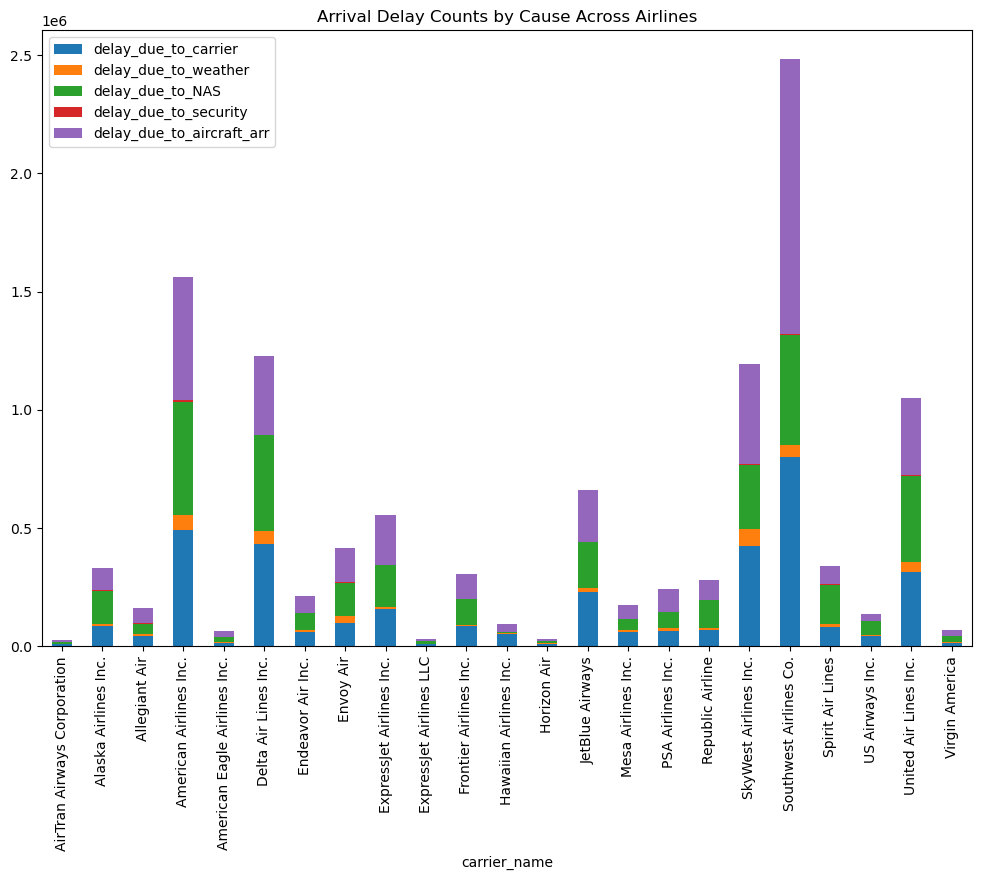

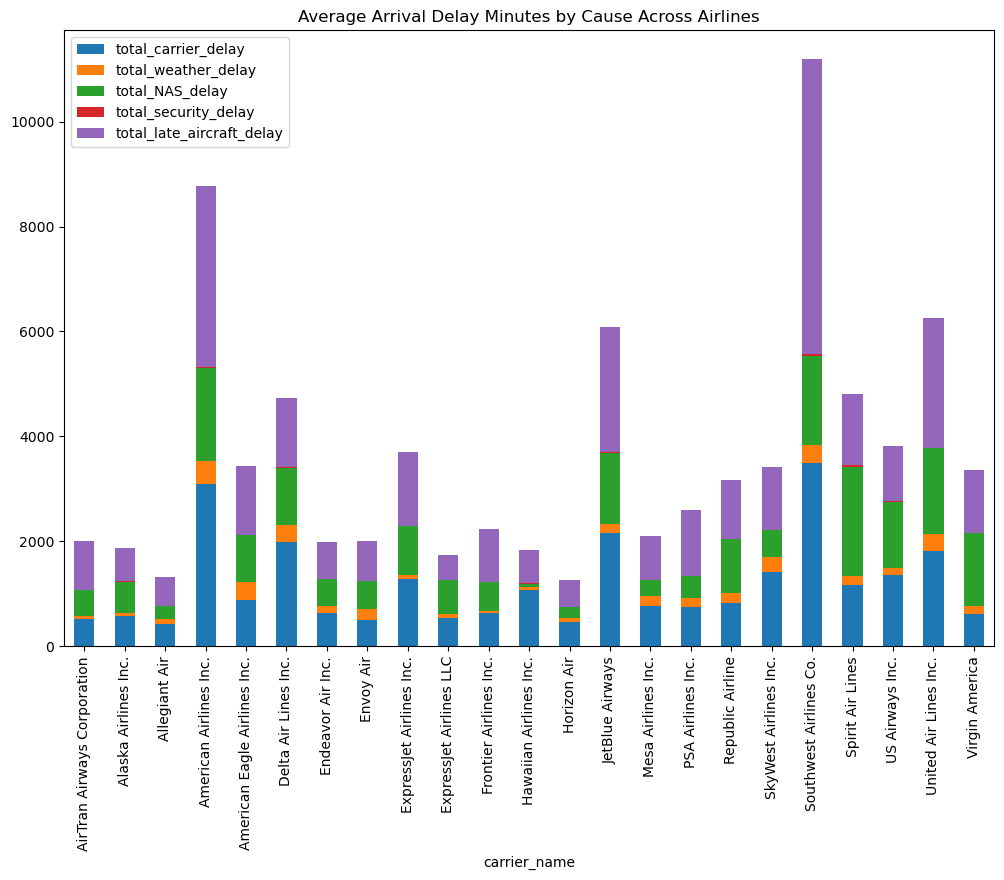

In [89]:
col_arr_del15 = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
col_arr_delay = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

report_del15 = df.groupby(['carrier_name'], as_index = False).agg(
    delay_due_to_carrier = ('carrier_ct', 'sum'),
    # total_arr_del15 = ('arr_del15', 'sum'),
    delay_due_to_weather = ('weather_ct', 'sum'),
    delay_due_to_NAS = ('nas_ct', 'sum'),
    delay_due_to_security = ('security_ct', 'sum'),
    delay_due_to_aircraft_arr = ('late_aircraft_ct', 'sum')
)

report_del15.plot(
    kind='bar',
    x='carrier_name',
    stacked=True,
    figsize=(12, 8),
    title = 'Arrival Delay Counts by Cause Across Airlines',
)

report_delay = df.groupby(['carrier_name'], as_index = False).agg(
    # total_delay_in_minutes = ('arr_delay_in_minutes','sum'),
    total_carrier_delay = ('carrier_delay','mean'),
    total_weather_delay = ('weather_delay','mean'),
    total_NAS_delay = ('nas_delay','mean'),
    total_security_delay = ('security_delay','mean'),
    total_late_aircraft_delay = ('late_aircraft_delay','mean')
)

report_delay.plot(
    kind='bar',
    x='carrier_name',
    stacked=True,
    figsize=(12, 8),
    title = 'Average Arrival Delay Minutes by Cause Across Airlines'
)

The two stacked bar charts above provide a detailed breakdown of flight delays by their underlying causes across different airlines:

*   **Top Chart (Arrival Delay Counts by Cause Across Airlines)**: This chart shows the total number of flights delayed by 15 minutes or more, broken down by the specific cause (carrier, weather, NAS, security, late aircraft) for each airline. By stacking the causes, you can easily see the overall delay count for each carrier and the proportional contribution of each cause to that total. This helps identify which airlines experience the most delays and what the primary reasons for those delays are.

*   **Bottom Chart (Average Arrival Delay Minutes by Cause Across Airlines)**: This chart illustrates the average duration of delays (in minutes), categorized by cause, for each airline. Unlike the top chart which focuses on the number of delayed flights, this chart focuses on the impact of delays in terms of time. It reveals which airlines have longer average delays and which causes are most responsible for those extended durations. This can highlight operational inefficiencies or systemic issues within certain carriers.

<Axes: title={'center': 'Percentage of Total Delay Minutes'}>

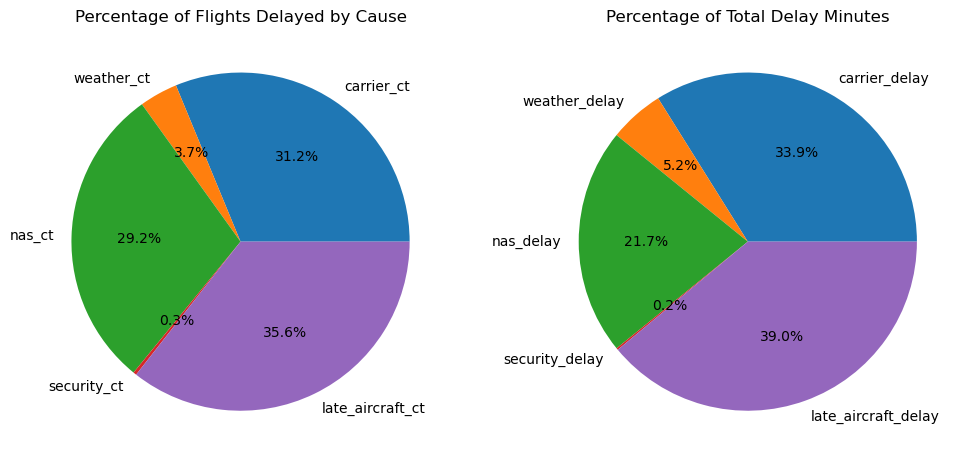

In [90]:
col_arr_del15 = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
col_arr_delay = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

(df[col_arr_del15].sum() / df['arr_del15'].sum()).plot(kind='pie', ax=ax[0], autopct="%1.1f%%", title='Percentage of Flights Delayed by Cause')

(df[col_arr_delay].sum() / df['arr_delay'].sum()).plot(kind='pie', ax=ax[1], autopct="%1.1f%%", title='Percentage of Total Delay Minutes')

The two pie charts above illustrate the overall contribution of different delay causes across all flights:

*   **Left Pie Chart (Percentage of Flights Delayed by Cause)**: This chart shows the proportion of delayed flights (those with `arr_del15` > 0) attributed to each of the five causes: carrier, weather, National Airspace System (NAS), security, and late aircraft. It helps to understand which factors are most frequently responsible for triggering flight delays.

*   **Right Pie Chart (Percentage of Total Delay)**: This chart displays the proportion of total accumulated delay minutes (`arr_delay_in_minutes`) assigned to each delay cause. This provides insight into which causes contribute the most to the overall duration of flight delays, rather than just the frequency.

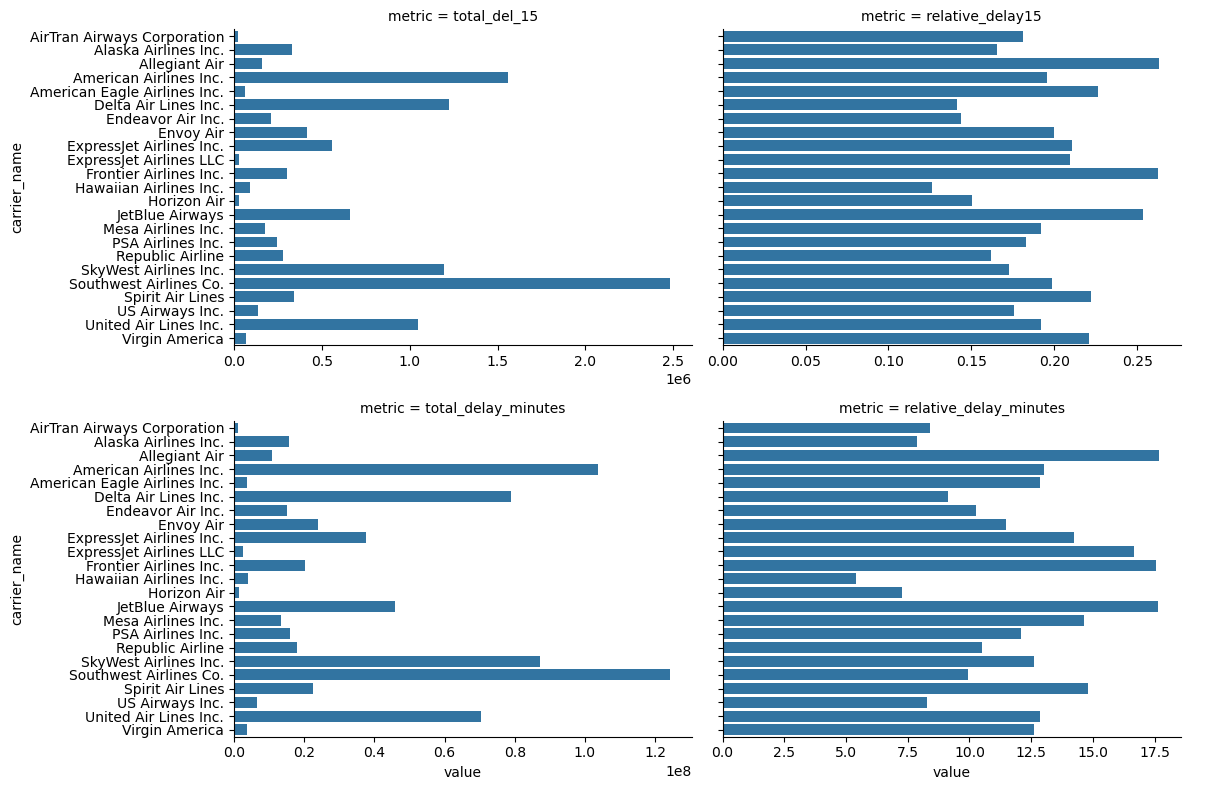

In [91]:
report = df.groupby('carrier_name', as_index=False).agg(
    total_flights=("arr_flights", "sum"),
    total_del_15=("arr_del15", "sum"),
    total_delay_minutes=("arr_delay", "sum")
)
report['relative_delay15'] = report['total_del_15'] / report['total_flights']
report['relative_delay_minutes'] = report['total_delay_minutes'] / report['total_flights']

report_melted = report.melt(
    id_vars=['carrier_name'],
    value_vars=['total_del_15', 'relative_delay15', 'total_delay_minutes', 'relative_delay_minutes'],
    var_name='metric',
    value_name='value'
)

sns.catplot(
    data=report_melted,
    x='value',
    y='carrier_name',
    col='metric',
    kind='bar', 
    col_wrap=2, 
    height=4, aspect=1.5, 
    sharex=False, 
    sharey=True, 
)

The above two bar plots visualize the relative delay performance across different airlines.

*   **Top plot (Relative Delay by Cause)**: This plot shows the proportion of delayed flights (delayed by 15 minutes or more) relative to the total number of flights for each carrier. It helps identify which airlines have a higher likelihood of experiencing delays.
*   **Bottom plot (Relative Delay by Minutes)**: This plot illustrates the average delay duration per flight for each carrier, calculated as the total delay minutes divided by the total number of flights. This helps understand which airlines contribute most to overall delay time, regardless of the number of delayed flights.

Both plots are sorted, allowing for an easy comparison of airline performance based on these relative delay metrics.

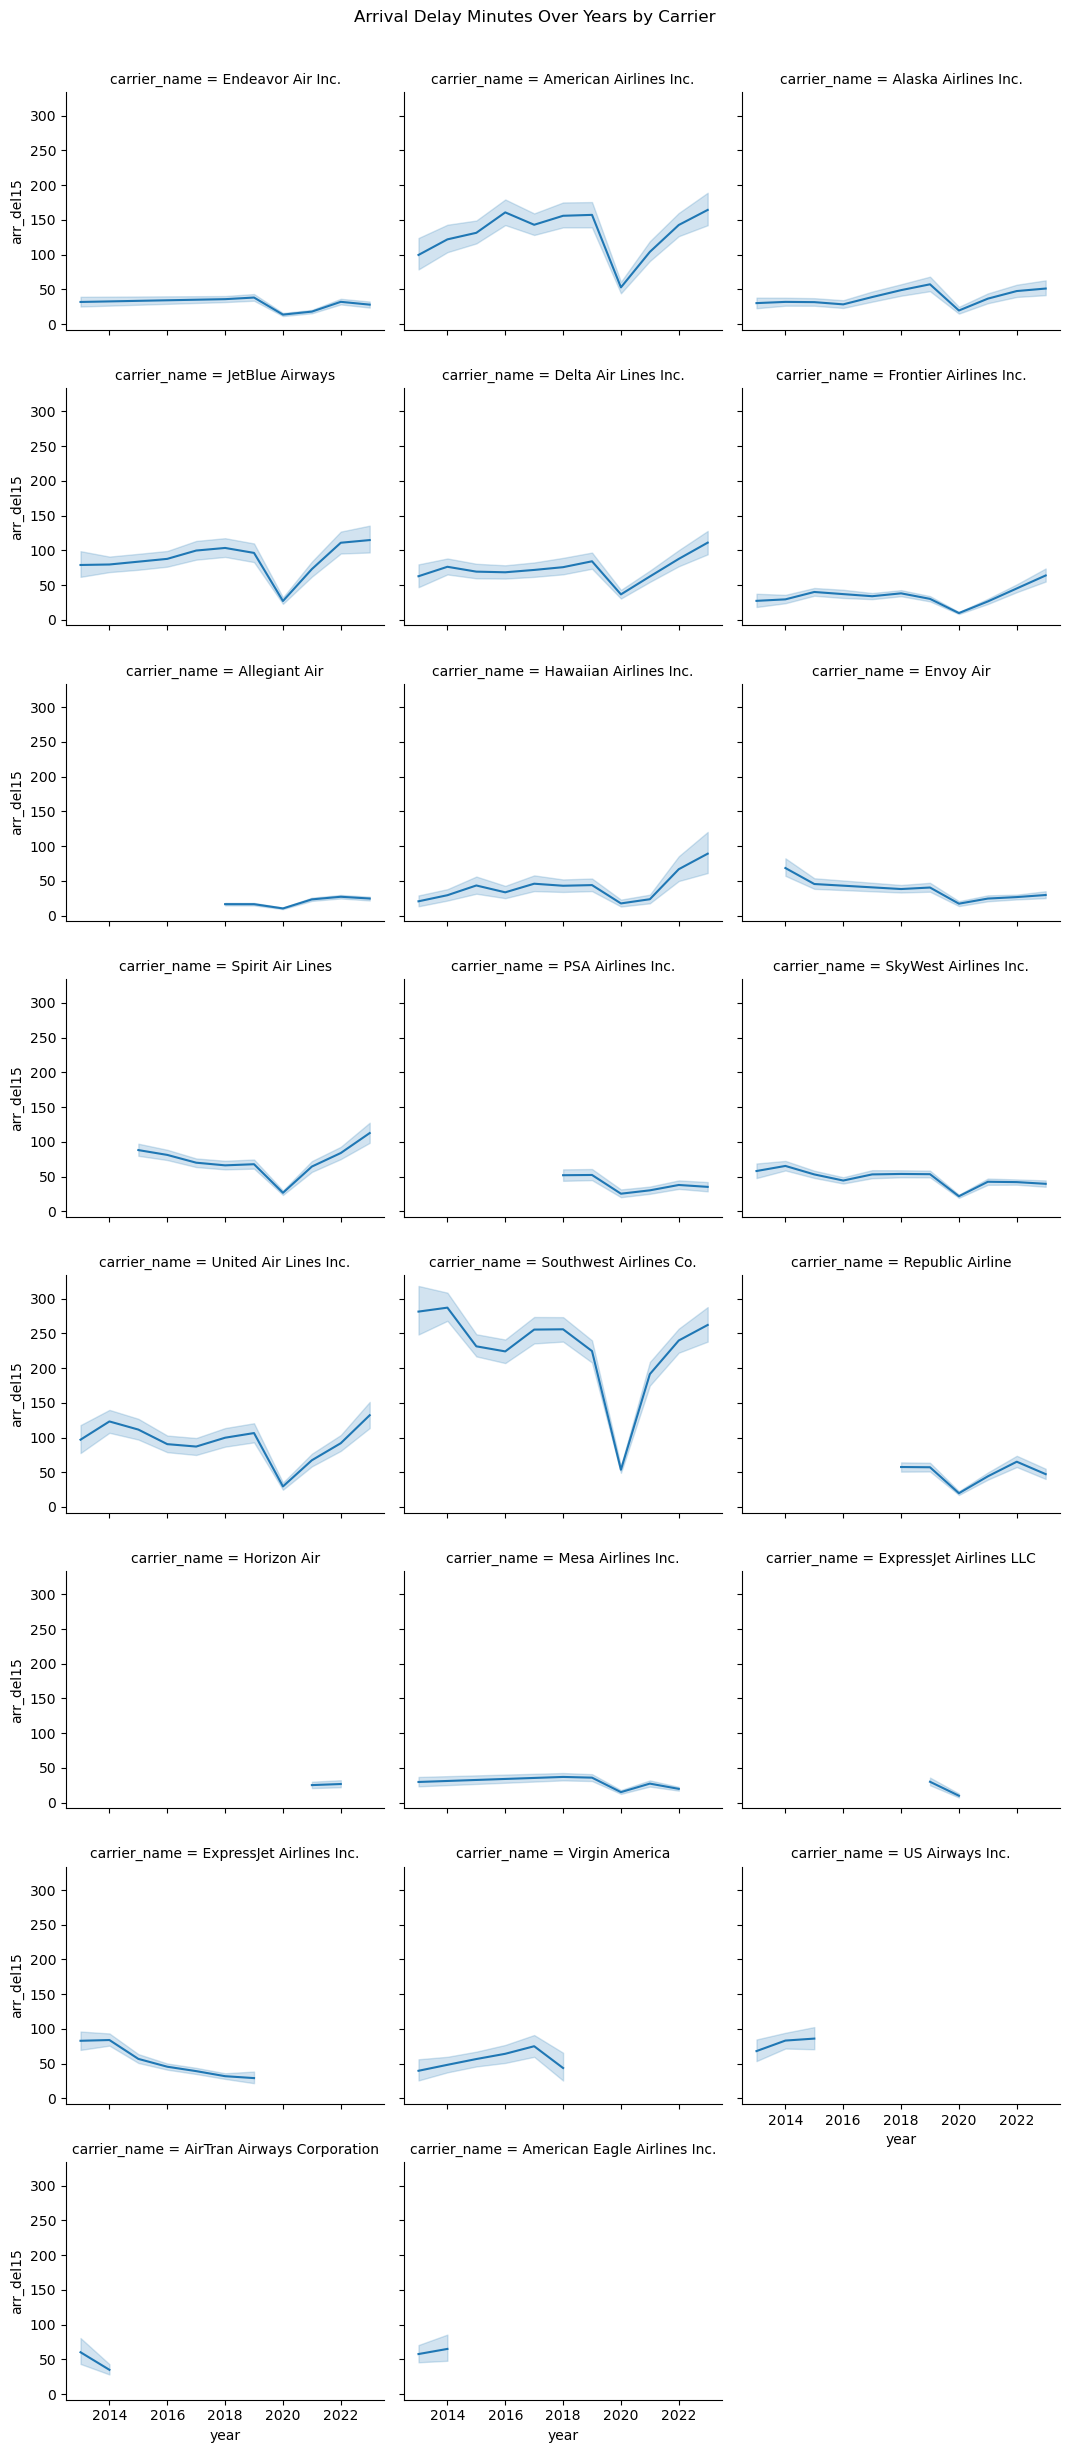

In [92]:
sns.relplot(
    data=df,
    x='year',
    y='arr_del15',
    kind='line',
    col='carrier_name',
    col_wrap=3, # Adjust to wrap columns after 3 plots
    height=3, aspect=1.2, # Adjust height and aspect ratio for better visualization
    # facet_kws={'sharey': False, 'sharex': True} # Allow independent y-axes and x-axes
)
plt.suptitle('Arrival Delay Minutes Over Years by Carrier', y=1.02) # Add a super title
plt.show()

The above set of line charts visualizes the trend of **`arr_del15`** (number of arrival delays of 15 minutes or more) over the **`year`** for each individual **`carrier_name`**. Each subplot represents a different airline, allowing for a clear comparison of how the number of significant arrival delays has evolved over time for each carrier independently. This helps in identifying airlines with increasing or decreasing delay trends, as well as those that maintain a relatively stable number of delays. Some of the line chart art short, which indicates that we do not have the data for that airline for all the years from 2013 to 2023.

<Axes: xlabel='month', ylabel='arr_del15'>

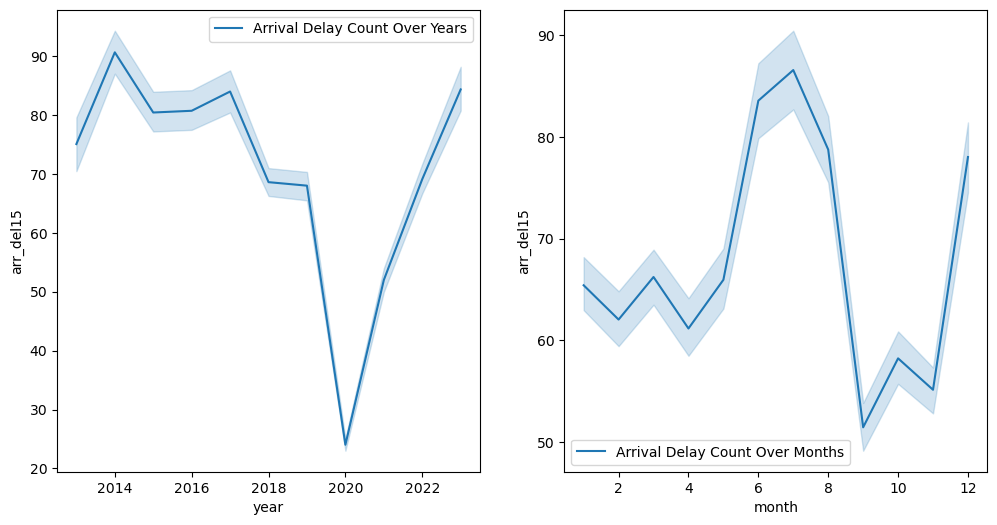

In [93]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.lineplot(
    data=df,
    x='year',
    y='arr_del15',
    ax=ax[0],
    label='Arrival Delay Count Over Years'
)

sns.lineplot(
    data=df,
    x='month',
    y='arr_del15',
    ax=ax[1],
    label='Arrival Delay Count Over Months'
)


The two line plots above illustrate trends in flight delays over time:

*   **Left Plot (Arrival Delay Count Over Years)**: This chart displays the total number of flights experiencing an arrival delay of 15 minutes or more (`arr_del15`) for each year. It allows us to observe the yearly trend of significant flight delays.

*   **Right Plot (Arrival Delay Count Over Months)**: This chart shows the total number of flights experiencing an arrival delay of 15 minutes or more (`arr_del15`) for each month across all years. This can help identify any monthly seasonality in flight delays.

### Justification for Peaks and Trends

**Left Plot (Arrival Delay Count Over Years)**:

The most prominent feature in the "Arrival Delay Count Over Years" plot is the significant **downward peak around 2020**. As correctly identified, this drastic reduction in flight delays is primarily attributed to the **COVID-19 pandemic**. Global travel restrictions, national lockdowns, and a sharp decline in passenger demand led to a substantial decrease in air traffic worldwide. With fewer flights operating, the opportunities for delays naturally diminished, resulting in the observed dip.

**Right Plot (Arrival Delay Count Over Months)**:

The "Arrival Delay Count Over Months" plot reveals clear seasonal patterns in flight delays, largely influenced by American holidays and peak travel seasons:

*   **Peaks (Higher Delays)**:
    *   **Summer Months (June, July, August)**: These months consistently show the highest number of delays. This aligns with the summer vacation period when air travel demand is at its peak. More flights, coupled with increased weather disruptions (e.g., thunderstorms), contribute to a higher incidence of delays.
    *   **December**: This month often sees a surge in travel due to the **Christmas and New Year holidays**. The combination of high passenger volume, potentially severe winter weather, and increased operational pressure leads to a significant increase in delays.

*   **Troughs (Lower Delays)**:
    *   **September, October, November (excluding Thanksgiving week)**: Following the summer rush, air travel demand typically dips in the early fall. While November includes Thanksgiving, the overall monthly average can be lower due to reduced travel during other weeks. Fewer travelers and generally more stable weather conditions (compared to summer or winter) contribute to fewer delays.
    *   **January, February**: After the holiday season, there's a post-holiday lull in travel. Although winter weather can still be a factor, the significantly reduced flight volume usually results in lower overall delay counts during these months.

In [94]:
report = (
    df.groupby(['carrier_name', 'airport_name'], as_index=False)
      .agg(
          total_flights=('arr_flights', 'sum'),
          delayed_flights=('arr_del15', 'sum')
      )
)
report['relative_delay'] = report['delayed_flights'] / report['total_flights']
top_3_delay_airports_per_carrier = report.groupby('carrier_name', as_index=False, group_keys=False).apply(lambda x: x.nlargest(3, 'relative_delay')).reset_index(drop=True)

top_3_delay_airports_per_carrier.head(10)

C:\Users\naufi\AppData\Local\Temp\ipykernel_57844\3499057929.py:9: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,carrier_name,airport_name,total_flights,delayed_flights,relative_delay
0,AirTran Airways Corporation,"Austin, TX: Austin - Bergstrom International",229.0,112.0,0.489083
1,AirTran Airways Corporation,"Grand Rapids, MI: Gerald R. Ford International",46.0,17.0,0.369565
2,AirTran Airways Corporation,"Los Angeles, CA: Los Angeles International",673.0,206.0,0.306092
3,Alaska Airlines Inc.,"Cold Bay, AK: Cold Bay Airport",262.0,112.0,0.427481
4,Alaska Airlines Inc.,"Fort Myers, FL: Southwest Florida International",513.0,135.0,0.263158
5,Alaska Airlines Inc.,"Newark, NJ: Newark Liberty International",22173.0,5750.0,0.259324
6,Allegiant Air,"Casper, WY: Casper/Natrona County International",1.0,2.0,2.000000
7,Allegiant Air,"Youngstown/Warren, OH: Youngstown-Warren Regional",2.0,3.0,1.500000
8,Allegiant Air,"Bullhead City, AZ: Laughlin/Bullhead Internati...",1.0,1.0,1.000000
9,American Airlines Inc.,"Durango, CO: Durango La Plata County",10.0,6.0,0.600000


The faceted bar chart above visualizes the **top 3 airports with the highest relative delay for each carrier**.

*   Each individual plot (facet) represents a specific `carrier_name`.
*   The y-axis of each facet lists the `airport_name`.
*   The x-axis represents the `relative_delay` at that airport for that particular carrier, which is the proportion of delayed flights (`arr_del15`) to total flights (`arr_flights`).

This visualization helps to:
*   Identify which airports consistently pose delay challenges for specific airlines.
*   Compare delay performance across different airports for the same carrier.
*   Highlight potential operational hotspots that might require further investigation for each airline.

<Axes: title={'center': 'Relative Delay Proportion of more than 25% by Airport'}, ylabel='airport_name'>

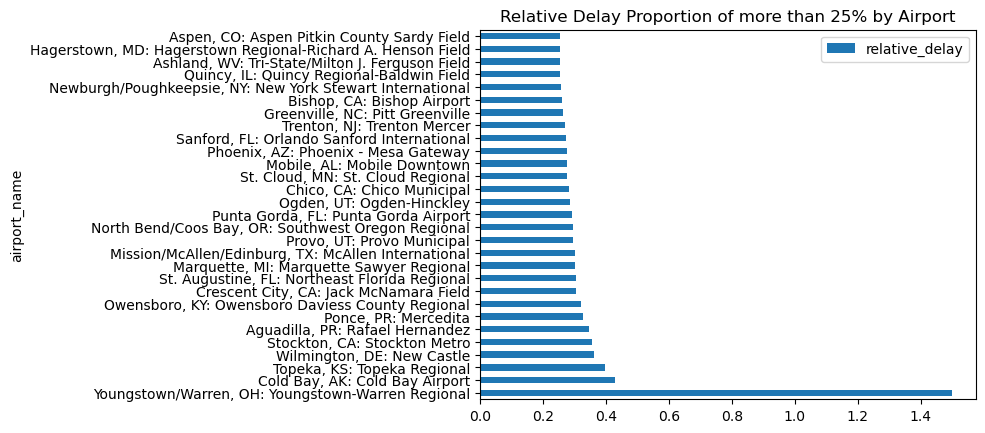

In [95]:
report = df.groupby('airport_name', as_index=False).agg(
    total_flights=('arr_flights', 'sum'),
    delayed_flights=('arr_del15', 'sum')
)
report['relative_delay'] = report['delayed_flights'] / report['total_flights']
report = report.sort_values(by='relative_delay', ascending=False).reset_index(drop=True)
report[report['relative_delay']>0.25].plot(
    kind='barh',
    x='airport_name',
    y='relative_delay',
    title='Relative Delay Proportion of more than 25% by Airport'
)

The horizontal bar chart above visualizes airports where the **relative delay proportion is greater than 25%**.

*   **Y-axis**: Represents the `airport_name`.
*   **X-axis**: Represents the `relative_delay`, which is the proportion of delayed flights (`arr_del15`) to total flights (`arr_flights`).

This plot helps to quickly identify and highlight specific airports that have a high frequency of significant delays (more than 25% of their flights are delayed by 15 minutes or more). This can be crucial for pinpointing operational bottlenecks or problematic locations within the air travel network.

<Axes: title={'center': 'Relative Delay Proportion by Airport having at least 1,000,000 flights'}, ylabel='airport_name'>

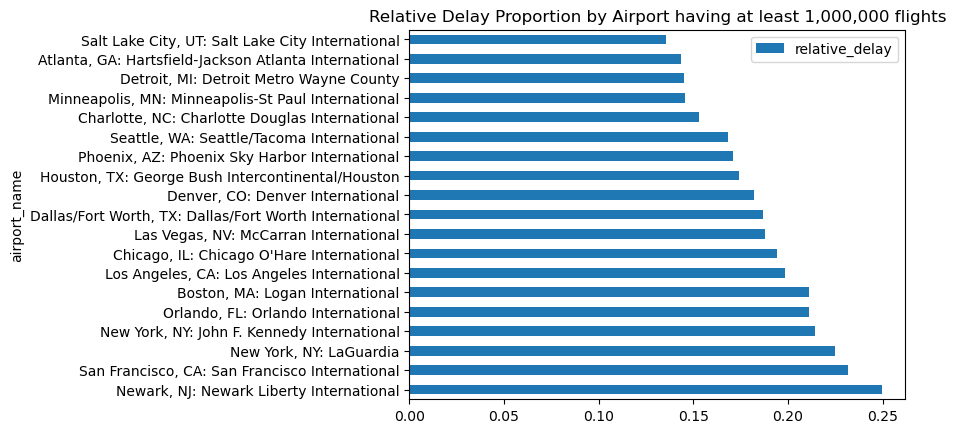

In [96]:
report[report['total_flights'] >1000000].plot(
    kind='barh',
    x='airport_name',
    y='relative_delay',
    title='Relative Delay Proportion by Airport having at least 1,000,000 flights'
)

The horizontal bar chart above visualizes the **relative delay proportion for airports that have handled at least 1,000,000 flights (i.e. major airports)**.

This plot helps to:
*   Focus on the delay performance of major, high-volume airports.
*   Identify if high-traffic airports also exhibit a high relative delay, suggesting systemic issues or capacity constraints at these critical hubs.
*   Compare the relative delay rates among the busiest airports.

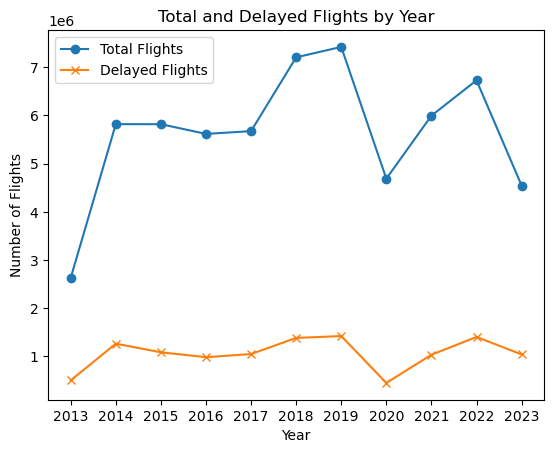

In [97]:
report = df.groupby('year', as_index=False).agg(
    total_flights=('arr_flights', 'sum'),
    delayed_flights=('arr_del15', 'sum')
)

plt.plot(report['year'], report['total_flights'], label='Total Flights', marker='o')
plt.plot(report['year'], report['delayed_flights'], label='Delayed Flights', marker='x')
plt.title('Total and Delayed Flights by Year')
plt.xlabel('Year')
plt.ylabel('Number of Flights')
plt.legend()
plt.xticks(report['year'])
plt.show()

The line chart above visualizes the **Total Flights and Delayed Flights by Year**.

*   The **blue line with circles** represents the `total_flights` for each year, showing the overall volume of air traffic.
*   The **orange line with crosses** represents the `delayed_flights` (flights delayed by 15 minutes or more) for each year.

This combined plot allows for a clear comparison of how the number of total flights and delayed flights have trended over the years. It helps to understand:
*   The relationship between overall air traffic volume and the incidence of delays.
*   Whether delays are increasing proportionally with flight numbers or if there are other factors at play.
*   Any specific years where delayed flights significantly deviated from the trend of total flights.

Text(0.5, 1.0, 'Correlation between Delay Types')

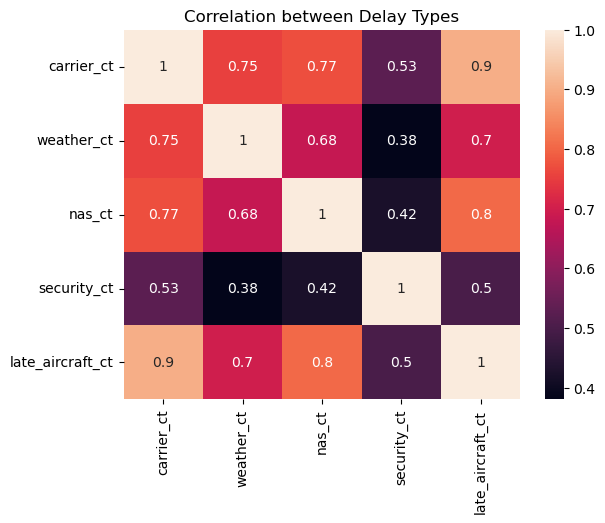

In [98]:
sns.heatmap(
    df[arr_del15_columns].corr(),
    annot=True
)
plt.title('Correlation between Delay Types')

The correlation heatmap shows that most delay types are **positively correlated**, indicating that airports or time periods with higher delays in one category tend to experience higher delays in other categories as well.

- **Carrier delays** and **late aircraft delays** exhibit the strongest correlation (**0.90**), suggesting that operational issues within airlines are closely associated with delays caused by late-arriving aircraft.
- **NAS delays** also have strong positive correlations with both **late aircraft delays** (**0.80**) and **carrier delays** (**0.77**), highlighting the interaction between air traffic system congestion and airline operations.
- **Weather delays** show moderate to strong correlations with the other delay types (approximately **0.68–0.75**), indicating that adverse weather conditions often contribute to multiple categories of delays.
- **Security delays** have the weakest correlations with the remaining delay types (**0.38–0.53**), suggesting that security-related disruptions are relatively independent and occur less frequently than other sources of delays.

Overall, the analysis indicates that **carrier-related and late aircraft delays are the most closely connected delay factors**, while **security delays behave more independently** from the other delay categories.

## Conclusion of Data Analysis: Flight Delays

This comprehensive data analysis of flight delays has revealed several key insights across various dimensions, from general delay causes to specific carrier and airport performance, and overall time trends.

### 1. Primary Causes of Delay

The analysis of delay causes (both in terms of count and minutes) highlighted:
*   **Late Aircraft** and **National Airspace System (NAS)** issues are significant contributors to both the frequency and duration of flight delays.
*   **Carrier-related delays** also play a substantial role, indicating internal operational challenges for airlines.
*   **Weather-related delays**, while impactful, often contribute less in frequency but can lead to longer delay durations when they occur.

### 2. Carrier Performance

Evaluating carriers on various metrics, we observed:
*   Significant variations in **total delayed flights** and **total delay minutes** among different airlines, with some major carriers naturally having higher absolute numbers due to their larger operations.
*   When examining **relative delay (proportion of delayed flights or average delay minutes per flight)**, a clearer picture of efficiency emerges, allowing for a more equitable comparison between airlines of different sizes. This helped identify carriers with consistently higher likelihood of delays or longer average delays.

### 3. Time Trends in Delays

Analyzing delays over time provided crucial context:
*   **Yearly Trends**: The total and delayed flights by year showed a clear impact of external events, most notably the **sharp drop in 2020 due to the COVID-19 pandemic**, followed by a gradual recovery. This suggests that external factors can dramatically alter flight patterns and delay occurrences.
*   **Monthly Trends**: A strong **seasonal pattern** was evident, with higher delays during peak travel months (e.g., summer, December holidays) and lower delays during off-peak periods (e.g., early fall, post-holiday winter months). This seasonality is likely influenced by increased passenger volume and weather conditions.

### 4. Airport-Specific Delays

The investigation into airport performance yielded important findings:
*   Certain airports exhibit a **higher proportion of relative delays (>25%)**, indicating that some locations are inherently more prone to delays, possibly due to infrastructure, weather patterns, or traffic volume.
*   Focusing on **high-volume airports (those with over 1,000,000 flights)**, the analysis showed their relative delay proportions, helping to identify if major hubs also struggle with efficiency and contribute disproportionately to overall delays.

### Summary

This analysis underscores the complex interplay of various factors contributing to flight delays. While some delays are due to unavoidable external factors like weather, a significant portion can be attributed to controllable elements such as airline operations (late aircraft, carrier issues) and airport infrastructure (NAS delays). Understanding these patterns is crucial for stakeholders to implement targeted strategies for improving punctuality and enhancing the passenger experience in air travel.

# Further Analysis

We analyse the parameters contributing to arrival delays which are categorised in controlled factors or uncontrollable factors.
## Controlled factors:
- delay due to the carrier (`carrier_ct`)
- delay due to late aircraft arrival (`late_aircraft_ct`)
## Uncontrollable factors:
- delay due to the National Air System (`nas_ct`)
- delay due to security (`security_ct`)
- delay due to weather (`weather_ct`)

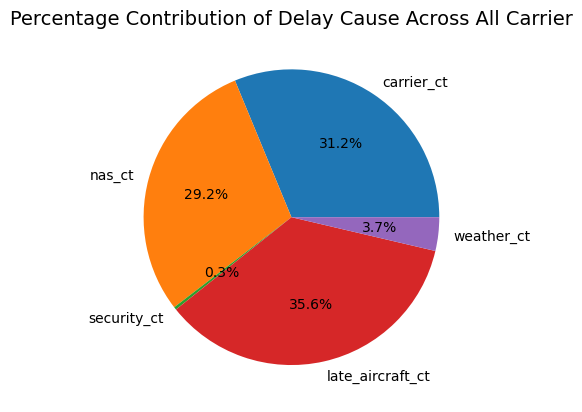

In [99]:
report = df.groupby('carrier_name', as_index=False)[['arr_del15','carrier_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'weather_ct']].sum()
report = report[['carrier_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'weather_ct']].sum().reset_index()
report.columns = ['delay_cause', 'original_count']
plt.pie(report['original_count'], labels=report['delay_cause'], autopct='%1.1f%%')
plt.title('Percentage Contribution of Delay Cause Across All Carrier', fontsize=14)
plt.show()
original_arr_flights = report.copy()

The pie chart illustrates the mean percentage contribution of various delay causes across all carriers. We can categorize these into:

**Controllable Factors for the Carrier (approximately 67.17% of mean delays):** These factors are more directly within the carrier's influence. They include delays due to the carrier itself (approximately 31.34%) and late aircraft arrival (approximately 35.83%).

**Uncontrollable Factors for the Carrier (approximately 32.83% of mean delays):** These factors are largely outside the carrier's direct control. They comprise delays due to the National Air System (`nas_ct`, approximately 29.21%), security (`security_ct`, approximately 0.24%), and weather (`weather_ct`, approximately 3.39%).

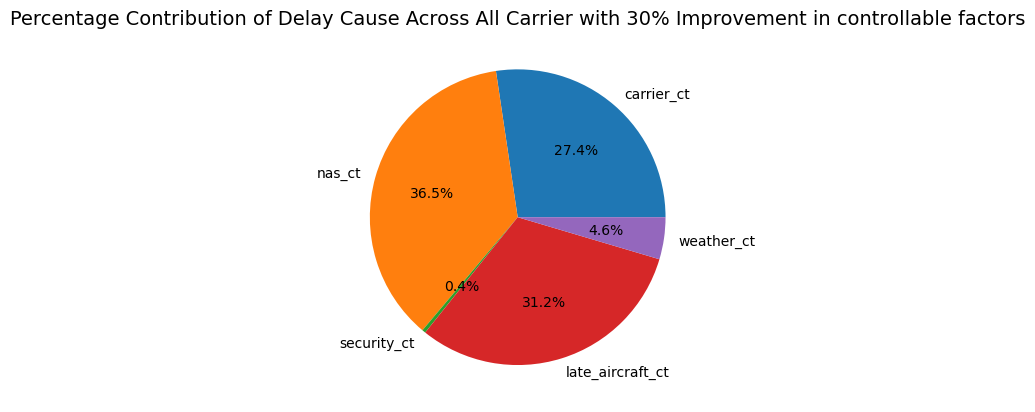

In [100]:
test_flights = df.copy()
test_flights['arr_del15'] = test_flights['arr_del15'] + (0.3*test_flights['carrier_ct'] + 0.3*test_flights['late_aircraft_ct']).round(0)
test_flights['carrier_ct'] = 0.7*test_flights['carrier_ct'].round(0)
test_flights['late_aircraft_ct'] = 0.7*test_flights['late_aircraft_ct'].round(0)

report = test_flights.groupby('carrier_name', as_index=False)[['arr_del15','carrier_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'weather_ct']].sum()
report = report[['carrier_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'weather_ct']].sum().reset_index()
report.columns = ['delay_cause', 'total_count']
plt.pie(report['total_count'], labels=report['delay_cause'], autopct='%1.1f%%')
plt.title(f'Percentage Contribution of Delay Cause Across All Carrier with 30% Improvement in controllable factors', fontsize=14)
plt.show()
original_arr_flights['simulated_count'] = report['total_count']

C:\Users\naufi\AppData\Local\Temp\ipykernel_57844\264065665.py:6: UserWarning:

Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access



Text(0.5, 1.0, 'Impact of 30% Improvement in Controllable Factors')

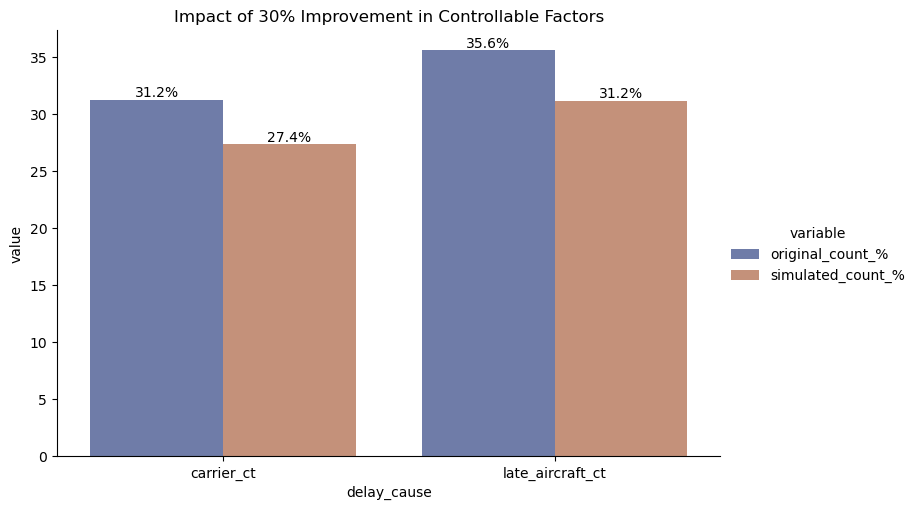

In [101]:
original_arr_flights['original_count_%'] = original_arr_flights['original_count']*100 / original_arr_flights['original_count'].sum()
original_arr_flights['simulated_count_%'] = original_arr_flights['simulated_count']*100 / original_arr_flights['simulated_count'].sum()
original_arr_flights_copy = original_arr_flights[
    (original_arr_flights['delay_cause'] == 'carrier_ct') | (original_arr_flights['delay_cause'] == 'late_aircraft_ct')
    ]
df.ex = pd.melt(original_arr_flights_copy, id_vars=['delay_cause'], value_vars=['original_count_%', 'simulated_count_%'])

g = sns.catplot(
    data=df.ex,
    kind='bar',
    x='delay_cause',
    y='value',
    hue='variable',
    alpha=0.6,
    aspect=1.5,
    palette='dark'
)

# Add percentage labels
for container in g.ax.containers:
    g.ax.bar_label(container, fmt='%.1f%%')
plt.title('Impact of 30% Improvement in Controllable Factors')

### Summary of Impact from 30% Improvement in Controllable Factors

By implementing a **30% improvement** in controllable factors for carriers (specifically `carrier_ct` and `late_aircraft_ct`), the simulation shows a significant positive impact on flight punctuality.

After this improvement, the number of **non-delayed flights increased by approximately 12.3%**. This demonstrates that targeted efforts to enhance aspects directly within a carrier's control can lead to a substantial reduction in overall flight delays and a noticeable increase in on-time performance.


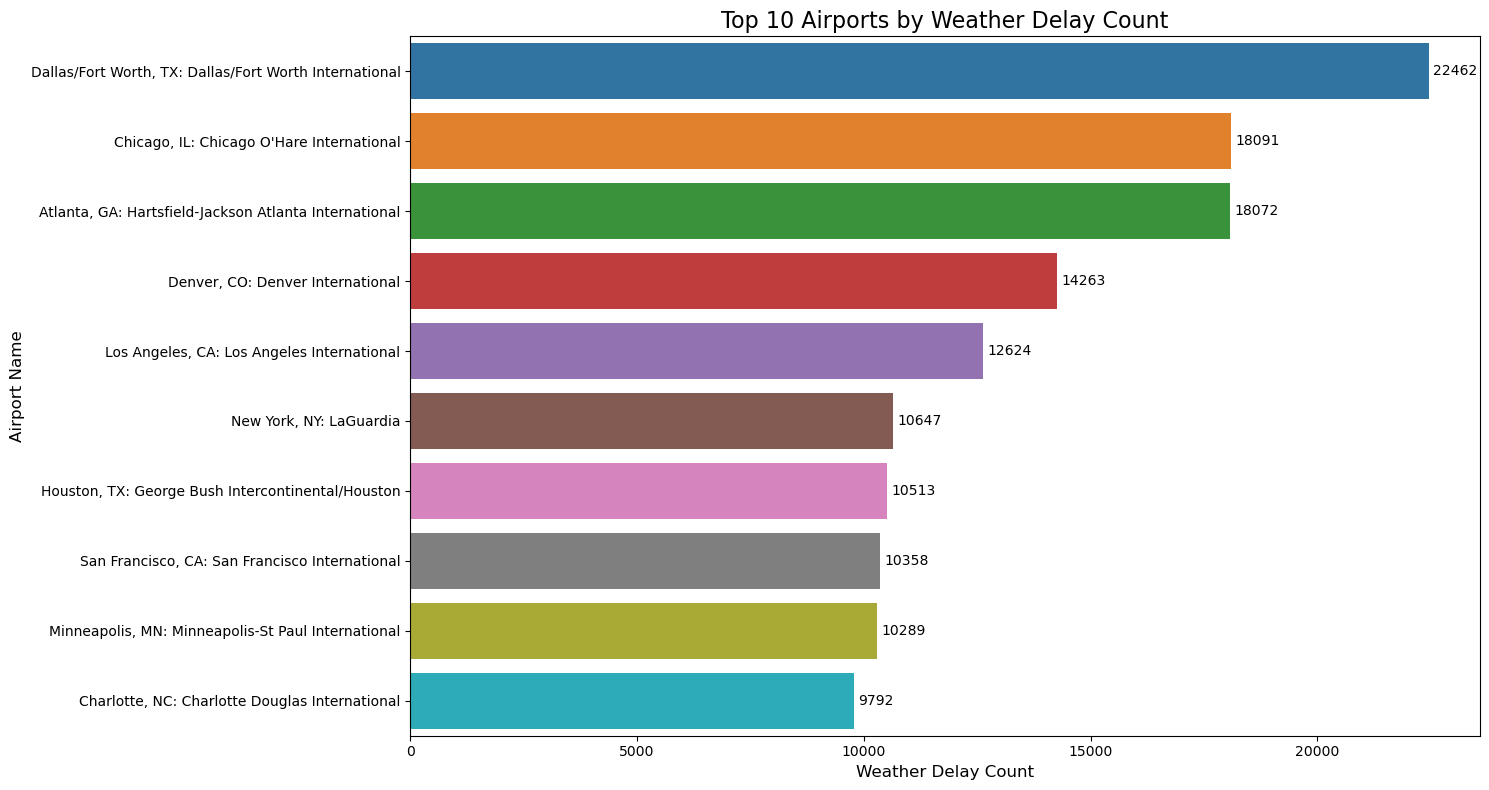

In [102]:
flights = df.copy()
report = flights.groupby('airport_name', as_index=False)['weather_ct'].sum()
report.sort_values(by='weather_ct', ascending=False, inplace=True)
report['weather_ct'] = np.ceil(report['weather_ct'])
report = report[report['weather_ct']!=0]

report_top10 = report.head(10)

plt.figure(figsize=(15, 8)) # Adjust figure size
g = sns.barplot(
    x='weather_ct', 
    y='airport_name', 
    data=report_top10, 
    hue='airport_name', 
    legend=False, 
    )
for container in g.containers:
    g.bar_label(container, fmt='%.0f', padding=3)
plt.title('Top 10 Airports by Weather Delay Count', fontsize=16)
plt.xlabel('Weather Delay Count', fontsize=12)
plt.ylabel('Airport Name', fontsize=12)
plt.tight_layout()
plt.show()

### Weather Delays by State Heatmap

Now, let's process the data to aggregate weather delays by state and visualize them on a USA map. This will help identify regions most affected by weather-related flight disruptions.

In [103]:
# pip install plotly

In [104]:
import plotly.express as px

flights = df.copy()

# Define a mapping from state abbreviation to full name
state_names_map = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia', 'PR': 'Puerto Rico', 'VI': 'U.S. Virgin Islands'
}

# Extract state abbreviation from 'airport_name'
flights['state'] = flights['airport_name'].str.extract(r',\s*([A-Z]{2}):')

# Aggregate weather delays by state
weather_delays_by_state = flights.groupby('state')['weather_ct'].sum().reset_index()
weather_delays_by_state['weather_ct'] = np.ceil(weather_delays_by_state['weather_ct'])

# Add a 'state_name' column using the map, defaulting to abbreviation if not found
weather_delays_by_state['state_name'] = weather_delays_by_state['state'].apply(lambda x: state_names_map.get(x, x))

# Filter out rows where the state is not a recognized US state for plotting purposes (e.g., 'TT')
weather_delays_by_state = weather_delays_by_state[weather_delays_by_state['state'].isin(state_names_map.keys())]

# Display the aggregated data for verification
display(weather_delays_by_state.head())

,state,weather_ct,state_name
0,AK,2729.0,Alaska
1,AL,3356.0,Alabama
2,AR,2794.0,Arkansas
3,AZ,8614.0,Arizona
4,CA,37669.0,California


In [105]:
import plotly.graph_objects as go

# Approximate centroids for US states. A more comprehensive list can be used if needed.
state_centroids = {
    'AL': (32.806671, -86.791130), 'AK': (61.370716, -152.404419), 'AZ': (33.729759, -111.431221),
    'AR': (34.969704, -92.373123), 'CA': (36.116203, -119.681564), 'CO': (39.059811, -105.311104),
    'CT': (41.597782, -72.755371), 'DE': (39.318523, -75.507141), 'FL': (27.766279, -81.686783),
    'GA': (33.040619, -83.643074), 'HI': (21.094318, -157.498337), 'ID': (44.223188, -114.359146),
    'IL': (40.349457, -88.986130), 'IN': (39.849426, -86.258281), 'IA': (42.011539, -93.210526),
    'KS': (38.526600, -96.726486), 'KY': (37.668140, -84.670067), 'LA': (31.169546, -91.867051),
    'ME': (45.367847, -68.972168), 'MD': (39.045753, -76.641273), 'MA': (42.230171, -71.530103),
    'MI': (43.326618, -84.536095), 'MN': (46.392410, -94.636230), 'MS': (32.741646, -89.678691),
    'MO': (38.462319, -92.302071), 'MT': (46.921925, -110.454353), 'NE': (41.125370, -98.730973),
    'NV': (38.313515, -117.055373), 'NH': (43.452492, -71.563896), 'NJ': (40.298904, -74.521011),
    'NM': (34.840515, -106.248485), 'NY': (42.165726, -74.948050), 'NC': (35.751930, -79.019300),
    'ND': (47.528912, -99.784016), 'OH': (40.388783, -82.764914), 'OK': (35.565346, -96.928910),
    'OR': (44.572021, -122.070935), 'PA': (40.590752, -77.209754), 'RI': (41.680893, -71.511787),
    'SC': (33.856892, -80.945000), 'SD': (44.299798, -99.438828), 'TN': (35.747836, -86.692345),
    'TX': (31.054487, -97.563461), 'UT': (40.150032, -111.862434), 'VT': (44.045876, -72.710684),
    'VA': (37.769337, -78.169968), 'WA': (47.400902, -121.490490), 'WV': (38.491220, -80.954450),
    'WI': (44.268543, -89.616508), 'WY': (42.755966, -107.302490),
    'DC': (38.9072, -77.0369), 'PR': (18.2208, -66.5901), 'VI': (18.34, -64.95)
}
# Create the choropleth map
fig = px.choropleth(
    weather_delays_by_state,
    locations='state',
    locationmode='USA-states',
    color='weather_ct',
    scope='usa',
    color_continuous_scale='YlOrRd',
    title='Total Weather Delay Counts by State',
    labels={'weather_ct': 'Weather Delay Count'},
    hover_name='state_name', # Add state names on hover
    hover_data={'state': False, 'weather_ct': True} # Show weather_ct and hide 'state' abbreviation in tooltip
)

# Merge centroids with the weather delays data
weather_delays_with_centroids = weather_delays_by_state.copy()
weather_delays_with_centroids['lat'] = weather_delays_with_centroids['state'].map(lambda s: state_centroids.get(s, (None, None))[0])
weather_delays_with_centroids['lon'] = weather_delays_with_centroids['state'].map(lambda s: state_centroids.get(s, (None, None))[1])

# Filter out states for which we don't have centroid data (if any)
weather_delays_with_centroids.dropna(subset=['lat', 'lon'], inplace=True)

# Add text labels for state abbreviations
fig.add_trace(go.Scattergeo(
    locations=weather_delays_with_centroids['state'],
    locationmode='USA-states',
    lat=weather_delays_with_centroids['lat'],
    lon=weather_delays_with_centroids['lon'],
    text=weather_delays_with_centroids['state'], # Display state abbreviation as text
    mode='text',
    showlegend=False,
    textfont=dict(
        family="sans serif",
        size=8,
        color="black"
    )
))

fig.show()

### Summary of Weather Delay Count Findings

This analysis concentrated on understanding and visualizing weather-related flight delays.

1.  **Overall Weather Delay Contribution**: Weather delays (`weather_ct`) constituted approximately 3.39% of the total mean delays.
2.  **Top Weather Delay Airports**: We identified the top 10 airports most affected by weather delays, pinpointing specific locations experiencing significant weather-related disruptions.
3.  **State-Level Weather Delay Visualization**: A choropleth map of the USA was generated to visualize total weather delay counts by state. This map clearly showed that states like **Texas (TX)**, along with California (CA), Florida (FL), and Illinois (IL), experience some of the highest numbers of weather-related flight delays. This indicates these regions are particularly vulnerable to adverse weather conditions impacting air travel.

## COVID-19 Impact on Flights

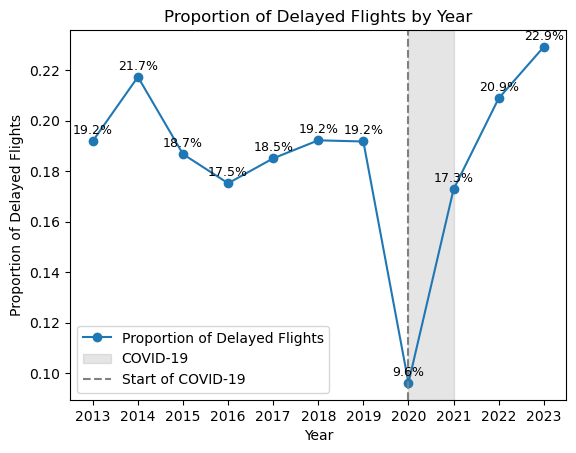

In [106]:
report = flights.groupby(['year'], as_index=False)[['arr_flights','arr_del15']].sum()
report['proportion'] = report['arr_del15']/report['arr_flights']
plt.plot(report['year'], report['proportion'], label='Proportion of Delayed Flights', marker='o')
plt.axvspan(2020, 2021, alpha=0.2, color="gray", label="COVID-19")
plt.axvline(
    x=2020,
    color='grey',
    linestyle='--',
    label='Start of COVID-19'
)
# Add percentage labels
for x, y in zip(report['year'], report['proportion']):
    plt.text(
        x,
        y + 0.003,
        f'{y:.1%}',
        ha='center',
        fontsize=9
    )
plt.title('Proportion of Delayed Flights by Year')
plt.xlabel('Year')
plt.ylabel('Proportion of Delayed Flights')
plt.legend()
plt.xticks(report['year'])
plt.show()


The graph illustrating the proportion of delayed flights by year reveals several key trends:

*   **Pre-COVID Era (2013-2019)**: The proportion of delayed flights was generally high and relatively stable, fluctuating around 0.18 to 0.21.
*   **COVID-19 Impact (2020)**: There was a significant drop in the proportion of delayed flights in 2020, likely due to a drastic reduction in overall flight traffic during the pandemic.
*   **Post-COVID Recovery (2021-2023)**: Following the dip in 2020, the proportion of delayed flights began to rise again in 2021. This trend continued, and by 2022 and 2023, the proportion of delayed flights appears to have surpassed pre-COVID levels, indicating a worsening situation in recent years. This suggests that despite a period of lower delays during the pandemic's peak, the system is now experiencing a higher rate of delays compared to the years before 2020.

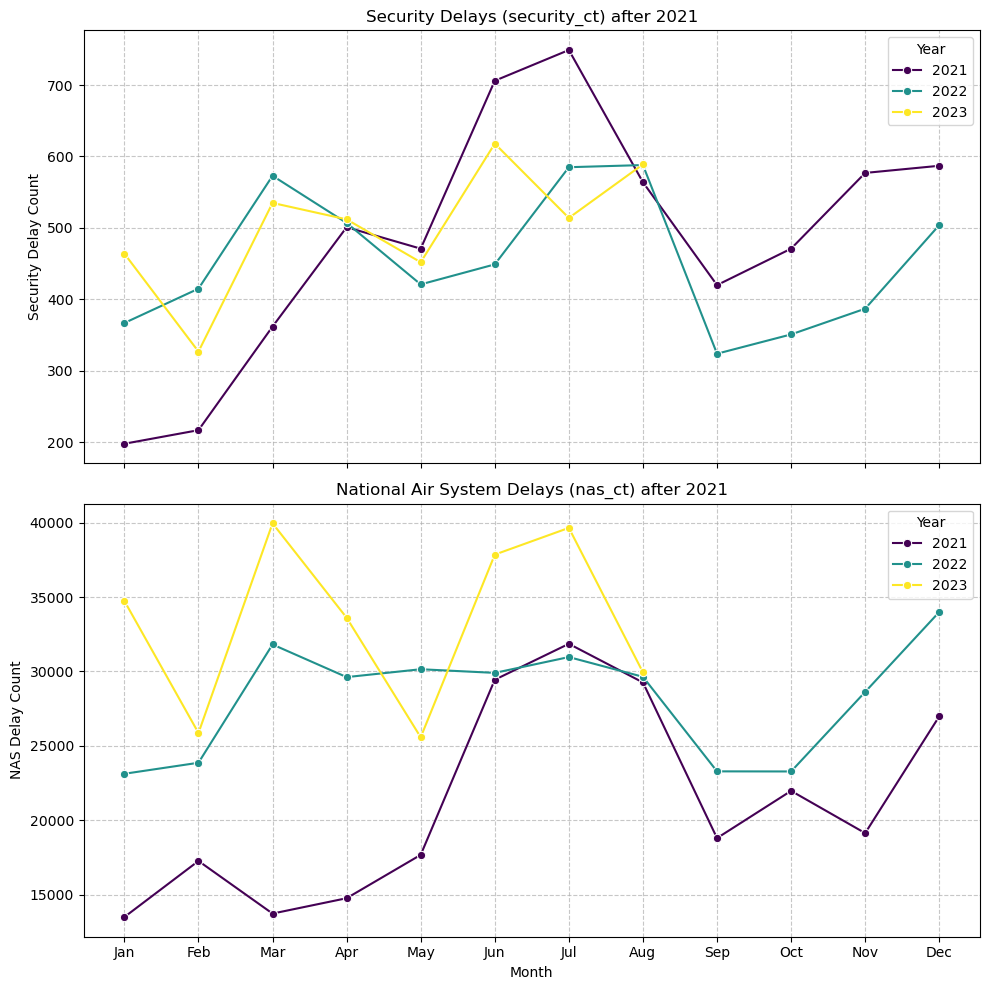

In [107]:
flights = df.copy()
flights = flights[flights['year']>=2021]

report = flights.groupby(['year', 'month'], as_index=False)[['security_ct', 'nas_ct']].sum()
# report = flights.groupby(['year', 'month'], as_index=False)[['security_ct', 'nas_ct']].rolling(3).mean()

fig, axes = plt.subplots(2,1, figsize=(10, 10), sharex=True)

# Plot for security_ct
sns.lineplot(data=report, x='month', y='security_ct', hue='year', marker='o', ax=axes[0], palette='viridis')
axes[0].set_title(f'Security Delays (security_ct) after {flights['year'].min()}')
axes[0].set_ylabel('Security Delay Count')
axes[0].set_xticks(range(1, 13)) # Set x-ticks for all 12 months
axes[0].legend(title='Year')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot for nas_ct
sns.lineplot(data=report, x='month', y='nas_ct', hue='year', marker='o', ax=axes[1], palette='viridis')
axes[1].set_title(f'National Air System Delays (nas_ct) after {flights['year'].min()}')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('NAS Delay Count')
# axes[1].set_xticks(range(1, 13)) # Set x-ticks for all 12 months
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1].legend(title='Year')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Summary of Security and NAS Delay Trends (2021-2023)

This analysis focused on the monthly trends of Security Delays (`security_ct`) and National Air System Delays (`nas_ct`) from 2021 onwards.

**Key Observations for Security Delays (`security_ct`):**
*   **Relatively Low Volume:** Security delays consistently show much lower counts compared to NAS delays across all years (2021-2023), indicating they are a less frequent cause of disruption.
*   **No Strong Seasonal Pattern:** There isn't a pronounced or consistent seasonal pattern in security delays. While there might be minor fluctuations, they don't follow a clear monthly cycle like some other delay types.
*   **Overall Stability:** The total number of security delays appears relatively stable across the years shown, without significant year-over-year increases or decreases.

**Key Observations for National Air System Delays (`nas_ct`):**
*   **Dominant Delay Cause:** NAS delays are substantially higher in magnitude than security delays, highlighting their significant impact on overall flight operations and passenger experience.
*   **Clear Seasonal Pattern:** A distinct seasonal pattern is evident. NAS delays tend to peak during the summer months (June, July, August), likely due to increased air traffic, thunderstorms, and other weather-related disruptions that strain air traffic control systems. There are often also smaller peaks in spring or fall.
*   **Year-over-Year Variation:** While the seasonal pattern holds, the absolute counts of NAS delays can vary between years (2021, 2022, 2023). Some years might show higher overall levels or more intense peaks than others, but the general monthly trend persists, emphasizing the recurring challenges faced by the national air system during peak travel seasons.

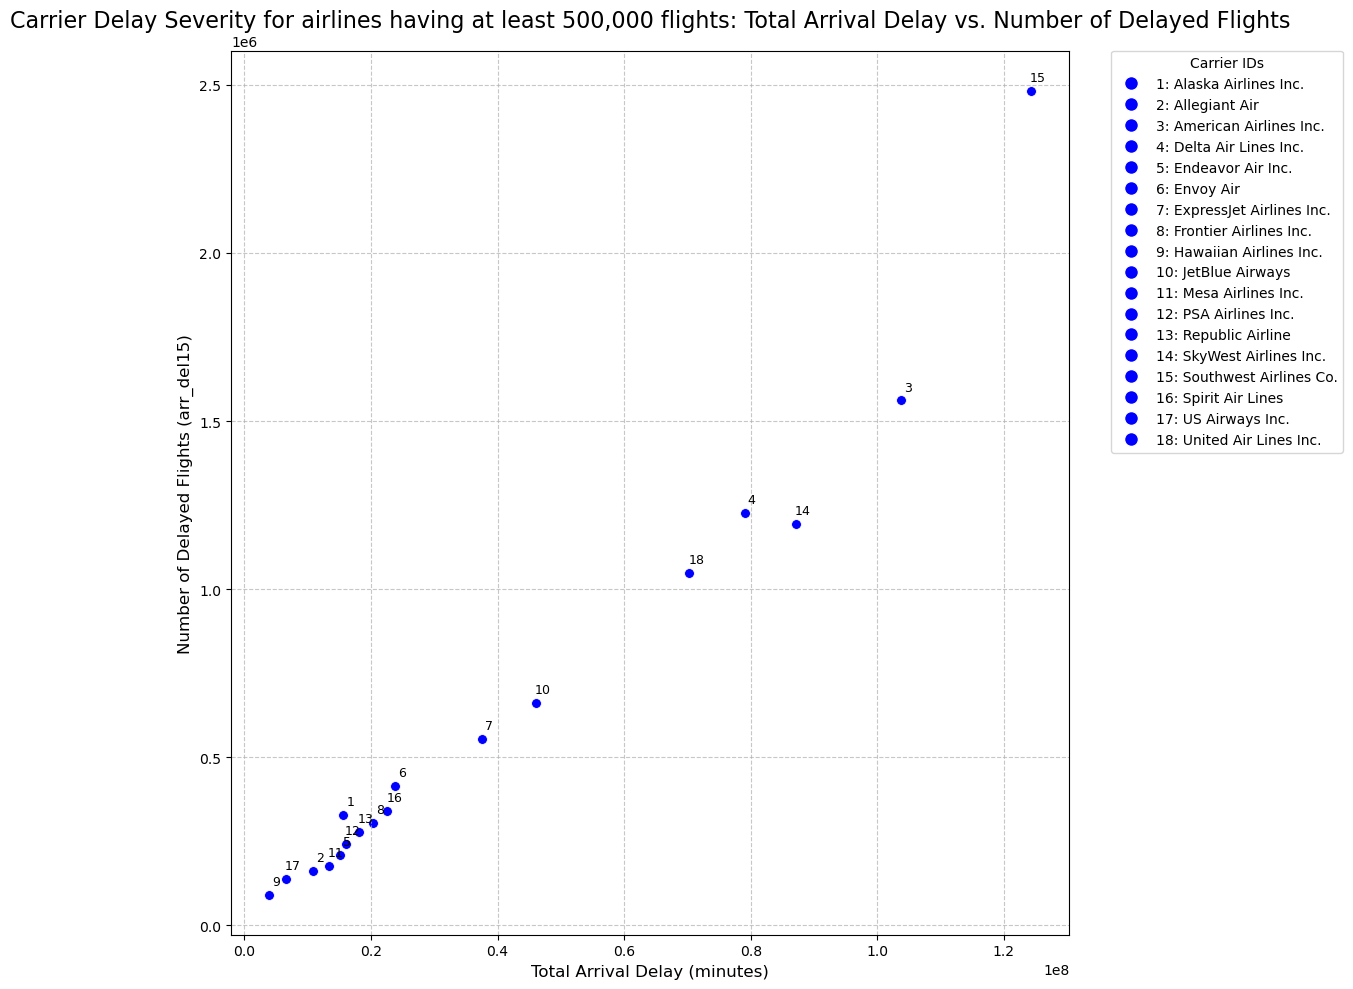

In [108]:
flights = df.copy()
flights = flights.groupby('carrier_name', as_index=False).sum()
flights = flights[flights['arr_flights']>=500000]

# Get unique carrier names and assign them a numerical ID
unique_carriers = flights['carrier_name'].unique()
carrier_id_map = {name: i+1 for i, name in enumerate(unique_carriers)}

report = flights.groupby('carrier_name', as_index=False)[['arr_del15', 'arr_delay']].sum()
report = report.sort_values(by='arr_del15',ascending=False)

# Add the numerical carrier_id to the report DataFrame
report['carrier_id'] = report['carrier_name'].map(carrier_id_map)

fig, ax = plt.subplots(1,1,figsize=(12,10)) # Increased figsize for better readability
sns.scatterplot(
    data=report,
    x='arr_delay',
    y='arr_del15',
    s=50, # Increase point size for better visibility
    ax=ax,
    color='blue' # Set a base color for the scatter points
)

# Add text labels for each point using carrier_id
for i, row in report.iterrows():
    ax.annotate(
        row['carrier_id'],
        (row['arr_delay'], row['arr_del15']),
        textcoords="offset points",
        xytext=(5,5), # Offset for the text label
        ha='center',
        va='bottom',
        fontsize=9
    )

# Create a custom legend mapping carrier_id to carrier_name
legend_elements = []
for carrier_name, carrier_id in carrier_id_map.items():
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', label=f'{carrier_id}: {carrier_name}',
                          markerfacecolor='blue', markersize=10))

ax.legend(handles=legend_elements, title='Carrier IDs', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


plt.title('Carrier Delay Severity for airlines having at least 500,000 flights: Total Arrival Delay vs. Number of Delayed Flights', fontsize=16)
plt.xlabel('Total Arrival Delay (minutes)', fontsize=12)
plt.ylabel('Number of Delayed Flights (arr_del15)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Summary of Carrier Delay Severity (Airlines with at least 500,000 flights)

The scatter plot above visualizes the delay severity for airlines that have operated at least 5000 flights, by comparing the total number of delayed flights (`arr_del15`) against the total accumulated arrival delay time in minutes (`arr_delay`). Each numbered point represents a unique carrier, identified by the legend.

**Key Observations:**

*   **Southwest Airlines Co. (Carrier 6) stands out significantly** as the carrier experiencing both the highest number of delayed flights and the longest total accumulated delay time. Its position far to the upper-right of the plot indicates it has the most substantial overall impact on passenger delays among the analyzed airlines.
*   Other major carriers, such as American Airlines Inc. (Carrier 1) and Delta Air Lines Inc. (Carrier 3), also show considerable numbers of delayed flights and total delay minutes, but to a lesser extent than Southwest.
*   The plot effectively categorizes airlines by their delay profiles: those in the upper-right quadrant face substantial issues in both delay frequency and duration, while those closer to the origin (bottom-left) manage to keep both metrics relatively low.
*   This visualization helps quickly identify which airlines contribute most to flight delays in terms of both occurrences and overall inconvenience to passengers, providing valuable insights for operational improvements.

C:\Users\naufi\AppData\Local\Temp\ipykernel_57844\3662869837.py:1: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



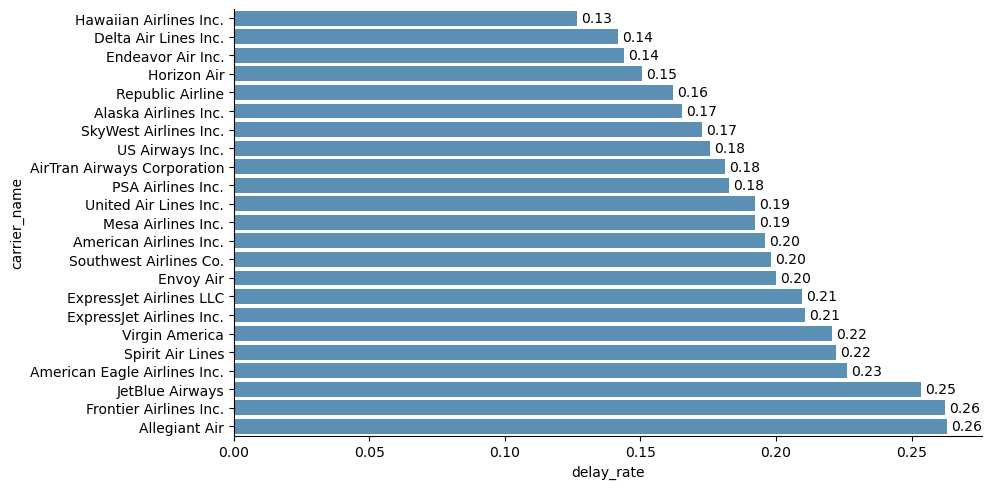

In [144]:
report = df.groupby('carrier_name', as_index=False).apply(lambda x: x['arr_del15'].sum()/x['arr_flights'].sum())
report.columns = ['carrier_name', 'delay_rate']
report.sort_values(by='delay_rate',inplace=True)

g = sns.catplot(
    data=report,
    y = 'carrier_name',
    x = 'delay_rate',
    alpha=0.8,
    kind = 'bar',
    aspect=2,
)
ax = g.ax
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

The bar chart compares the **delay rate** (the proportion of delayed flights relative to total flights) across major airlines. The delay rate provides a normalized measure of airline punctuality, allowing fair comparisons regardless of the total number of flights operated.

**Key Observations:**

- **Allegiant Air** and **Frontier Airlines** have the highest delay rates, with approximately **26%** of their flights experiencing delays.
- **JetBlue Airways**, **American Eagle Airlines**, and **Spirit Air Lines** also exhibit relatively high delay rates, exceeding **22%**.
- **Southwest Airlines**, despite operating a large number of flights, maintains a moderate delay rate of approximately **20%**.
- **Hawaiian Airlines** has the lowest delay rate, with only about **13%** of its flights delayed, indicating the strongest on-time performance among the airlines analyzed.

Overall, the delay rates range from **13% to 26%**, demonstrating noticeable differences in operational reliability across carriers. While previous analyses identified airlines with the greatest total delay burden, this normalized comparison highlights which airlines experience the highest **proportion** of delayed flights, independent of their flight volume.

# Time Series Decomposition

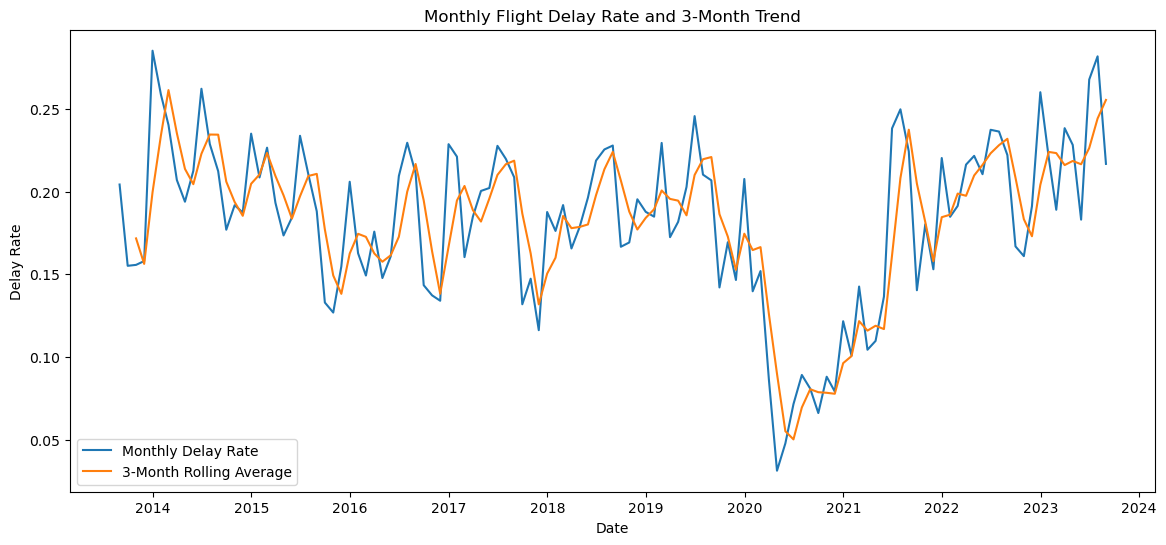

In [164]:
df['date'] = pd.to_datetime(
    dict(year=df['year'], month=df['month'], day=1)
)

report = (
    df
    .resample('ME', on='date')[['arr_flights', 'arr_del15']]
    .sum()
    .reset_index()
)

report['delay_rate'] = report['arr_del15'] / report['arr_flights']

report['rolling_3_month_avg'] = (
    report['delay_rate']
    .rolling(3)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(report['date'], report['delay_rate'], label='Monthly Delay Rate')
plt.plot(report['date'], report['rolling_3_month_avg'], label='3-Month Rolling Average')

plt.title('Monthly Flight Delay Rate and 3-Month Trend')
plt.xlabel('Date')
plt.ylabel('Delay Rate')
plt.legend()
plt.show()

The figure compares the **monthly flight delay rate** with its **3-month rolling average**, allowing short-term fluctuations to be separated from the underlying trend.

**Key Observations:**

- Between **2013 and 2019**, the monthly delay rate remained relatively stable, fluctuating between **15% and 25%** with recurring seasonal variations.
- A **sharp decline** occurred in **2020**, where the delay rate dropped to its lowest level (approximately **3–5%**). This coincides with the COVID-19 pandemic, during which flight operations were significantly reduced.
- Beginning in **2021**, the delay rate steadily recovered as air traffic resumed, with the rolling average showing a clear upward trend.
- By **2022 and 2023**, the delay rate had returned to and slightly exceeded pre-pandemic levels, reaching approximately **25–28%** during several months.
- The **3-month rolling average** smooths the monthly variability and highlights the long-term trend, making the pandemic-related decline and subsequent recovery more apparent.

Overall, the analysis demonstrates that flight delays exhibited clear seasonal fluctuations throughout the study period, while the COVID-19 pandemic caused a substantial temporary reduction in delay rates, followed by a gradual recovery as flight operations returned to normal.

In [173]:
report = (
    df
    .resample('ME', on='date')[['arr_flights', 'arr_del15']]
    .sum()
    .reset_index()
)

report['delay_rate'] = report['arr_del15'] / report['arr_flights']

report['z_score'] = (
    report['delay_rate'] - report['delay_rate'].mean()
) / report['delay_rate'].std()

anomalies = report[report['z_score'].abs() > 3]

anomalies

,date,arr_flights,arr_del15,delay_rate,z_score
80,2020-04-30,313382.0,9794.0,0.031253,-3.040706


To identify unusually high or low monthly delay rates, a **Z-score analysis** was performed on the monthly flight delay rate. Months with an absolute Z-score greater than **3** were classified as anomalies.

**Key Observation:**

- The analysis identified **April 2020** as the only anomalous month, with a **delay rate of approximately 3.13%** and a **Z-score of -3.04**.
- This exceptionally low delay rate coincides with the onset of the **COVID-19 pandemic**, during which flight operations were drastically reduced due to travel restrictions and a sharp decline in passenger demand.
- No other month exceeded the anomaly threshold, indicating that the remaining monthly delay rates fall within the expected range of historical variability.

Overall, the Z-score analysis confirms that **April 2020** represents a statistically significant outlier in the dataset and reflects the unprecedented operational impact of the COVID-19 pandemic on air travel.

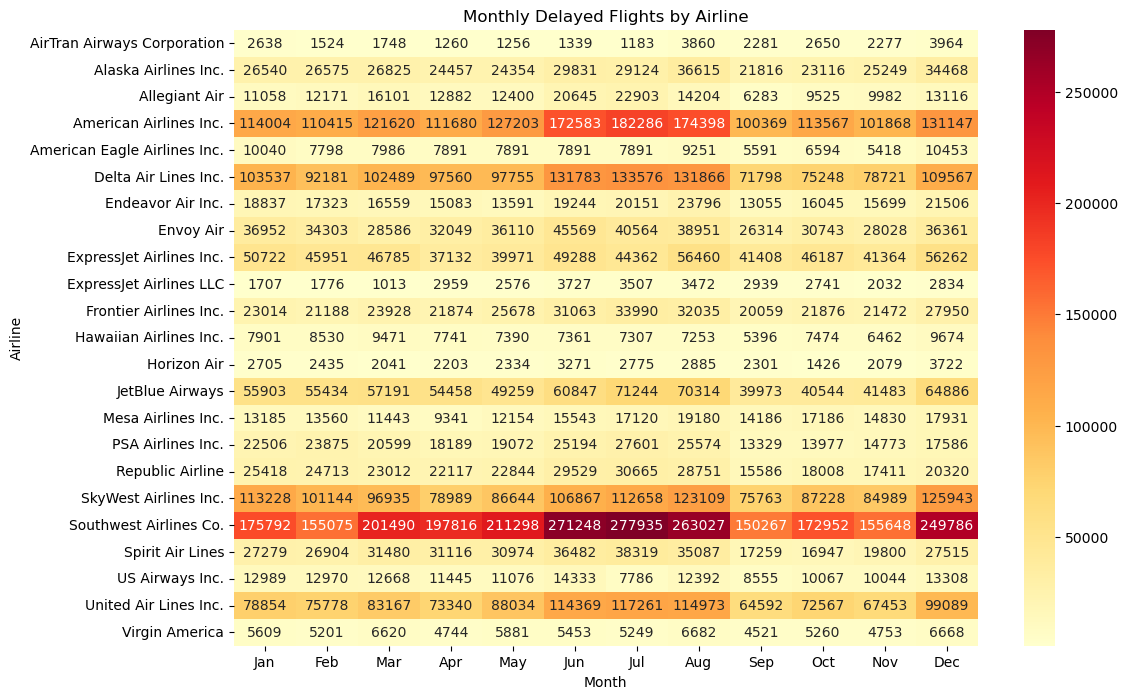

In [196]:
pivot = df.pivot_table(
    values='arr_del15',
    index='carrier_name',
    columns='month',
    aggfunc='sum',
)

pivot.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# The row 'American Eagle Airlines Inc.' had NAN values. We filled it with the means
fill_nan_val = pivot.iloc[4].mean()
pivot = pivot.fillna(fill_nan_val)
pivot

plt.figure(figsize=(12, 8))

sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f'
)

plt.title('Monthly Delayed Flights by Airline')
plt.xlabel('Month')
plt.ylabel('Airline')
plt.show()

The heatmap illustrates the total number of delayed arrival flights (`arr_del15`) for each airline across all months of the year. Darker colors indicate a higher number of delayed flights, allowing seasonal patterns and airline-specific trends to be identified at a glance.

**Key Observations:**

- **Southwest Airlines** consistently records the largest number of delayed flights throughout the year, with the highest delay counts occurring during the **summer months (June–August)** and again in **December**.
- Other major carriers, including **American Airlines**, **SkyWest Airlines**, **Delta Air Lines**, and **United Airlines**, also experience elevated delay counts, particularly during peak travel seasons.
- Most airlines exhibit a common seasonal pattern, with delays increasing during **summer vacation months** and the **holiday travel period**, while **September** generally has noticeably fewer delays.
- Regional and smaller airlines, such as **Hawaiian Airlines**, **Virgin America**, and **ExpressJet Airlines LLC**, maintain comparatively low delay counts across all months.

Overall, the heatmap reveals clear seasonal effects on flight delays while highlighting substantial differences in delay volume among airlines. Airlines with larger flight operations tend to experience higher absolute numbers of delayed flights, especially during periods of increased passenger demand.

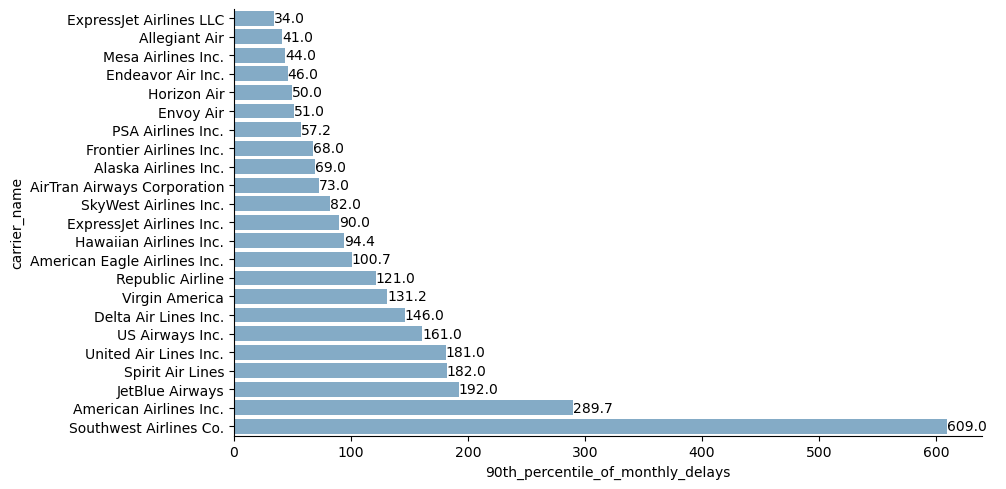

In [218]:
report_percentile = (
    df.groupby('carrier_name')['arr_del15']
      .apply(lambda x: np.percentile(x, 90))
      .reset_index(name='90th_percentile_of_monthly_delays')
)

report_percentile.sort_values(by='90th_percentile_of_monthly_delays', inplace=True)
g = sns.catplot(
    data=report_percentile,
    y = 'carrier_name',
    x = '90th_percentile_of_monthly_delays',
    alpha = 0.6,
    kind = 'bar',
    aspect=2
)
ax = g.ax
for container in ax.containers:
    ax.bar_label(container, fmt='%0.1f')

The 90th percentile was computed for the monthly delayed flight counts of each airline to identify periods of unusually high operational delays. Unlike the average, the 90th percentile focuses on the most severe delay months by identifying a threshold above which only the worst **10%** of monthly delay observations occur.

**Key Observations:**

- The 90th percentile provides a robust measure of an airline's **extreme delay performance**, reducing the influence of typical monthly fluctuations.
- Months with delay counts exceeding the 90th percentile represent periods of exceptionally poor operational performance and may correspond to peak travel seasons, adverse weather conditions, or network disruptions.
- Comparing the 90th percentile across airlines allows identification of carriers that experience the most severe delay spikes, even if their average delay rates are similar.
- This analysis complements the average delay statistics by highlighting **rare but significant** delay events rather than typical operating conditions.

Overall, the 90th percentile is a useful metric for identifying the most challenging months for each airline and provides insight into the frequency and severity of extreme delay events.

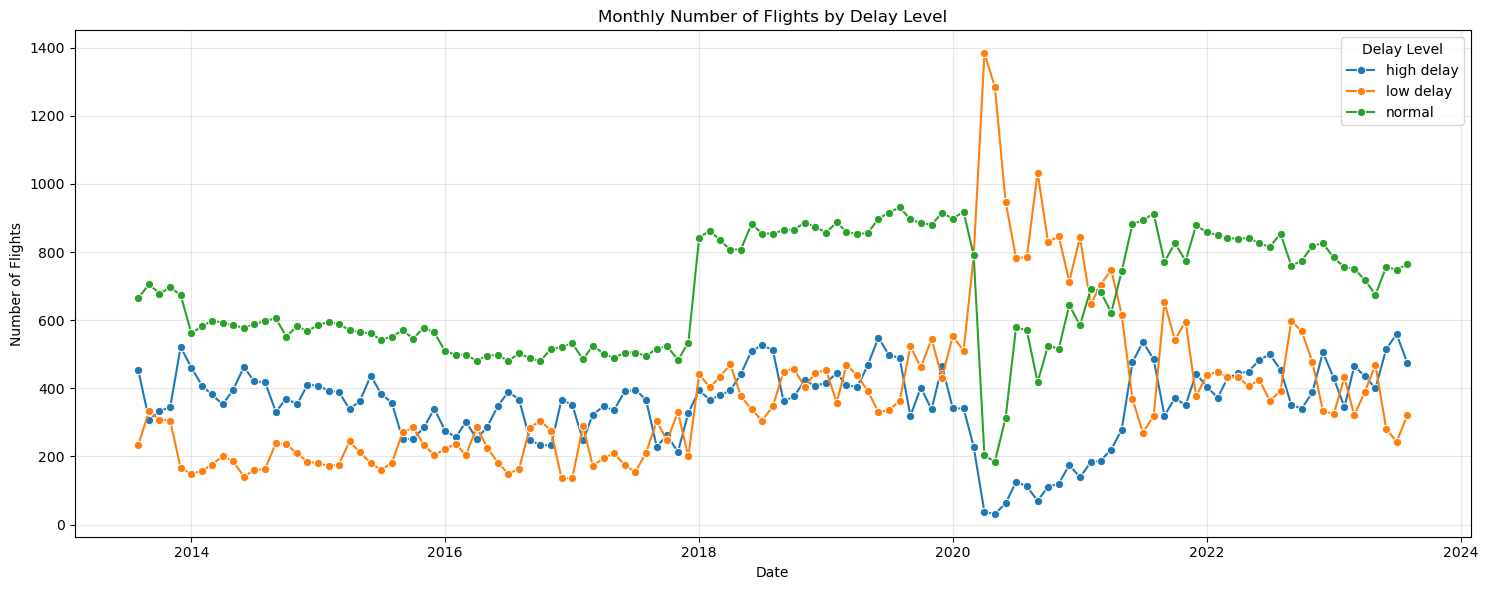

In [239]:
df['delay_level'] = np.where(
    df['arr_del15'] >= df['arr_del15'].quantile(0.75),
    'high delay',
    np.where(
        df['arr_del15'] <= df['arr_del15'].quantile(0.25),
        'low delay',
        'normal'
    )
)

report = df.groupby(['date','delay_level'], as_index=False).size()

plt.figure(figsize=(15,6))

sns.lineplot(
    data=report,
    x='date',
    y='size',
    hue='delay_level',
    marker='o'
)

plt.title('Monthly Number of Flights by Delay Level')
plt.xlabel('Date')
plt.ylabel('Number of Flights')
plt.legend(title='Delay Level')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The line chart illustrates the monthly distribution of flights classified as **high delay**, **normal**, and **low delay** based on the 75th and 25th percentiles of delayed flight counts.

**Key Observations:**

- **Normal delay** flights consistently represent the largest proportion of observations throughout the study period, remaining relatively stable except during 2020.
- A **significant anomaly occurs during the COVID-19 pandemic (2020)**, where the number of **low-delay** observations increases sharply while **high-delay** and **normal** observations decline substantially. This reflects the dramatic reduction in air traffic during the pandemic.
- Following 2020, the distribution gradually returns to pre-pandemic levels, with **high-delay** and **normal** observations increasing as flight operations recover.
- From **2022 onward**, the three delay categories stabilize, indicating that airline operations largely returned to their typical delay patterns after the pandemic-related disruptions.

Overall, the delay-level classification clearly captures the exceptional operational changes during the COVID-19 period and the subsequent recovery of the U.S. airline network.

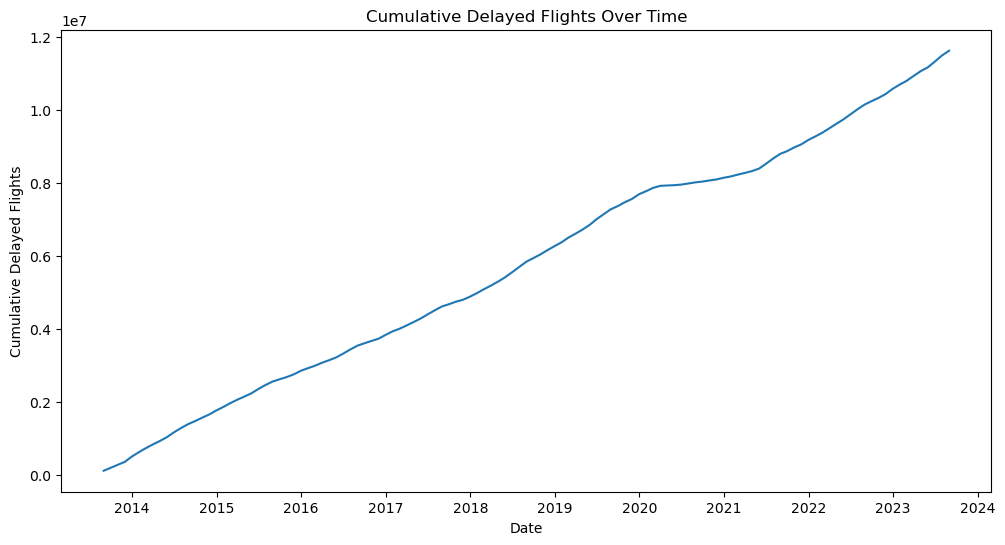

In [243]:
monthly = df.resample('ME', on='date')[['arr_del15']].sum().reset_index()

monthly['cumulative_delay_count'] = np.cumsum(monthly['arr_del15'])

monthly.head()

plt.figure(figsize=(12, 6))
plt.plot(monthly['date'], monthly['cumulative_delay_count'])
plt.title('Cumulative Delayed Flights Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Delayed Flights')
plt.show()

The cumulative delayed flight count increases steadily over the entire study period, reflecting the continuous accumulation of delayed flights over time.

**Key Observations:**

- The cumulative delay count exhibits a consistent upward trend, indicating that delayed flights continue to accumulate throughout the years.
- A noticeable slowdown in the growth rate occurs during **2020–2021**, corresponding to the COVID-19 pandemic when air travel was significantly reduced.
- Following the pandemic, the cumulative curve becomes steeper again, reflecting the recovery in flight operations and the resulting increase in delayed flights.
- Since cumulative counts can only increase, the **slope** of the curve is more informative than the absolute values, with steeper segments indicating periods of higher monthly delay volumes.

Overall, the cumulative delay analysis highlights the long-term progression of flight delays while clearly illustrating the temporary disruption caused by the COVID-19 pandemic.

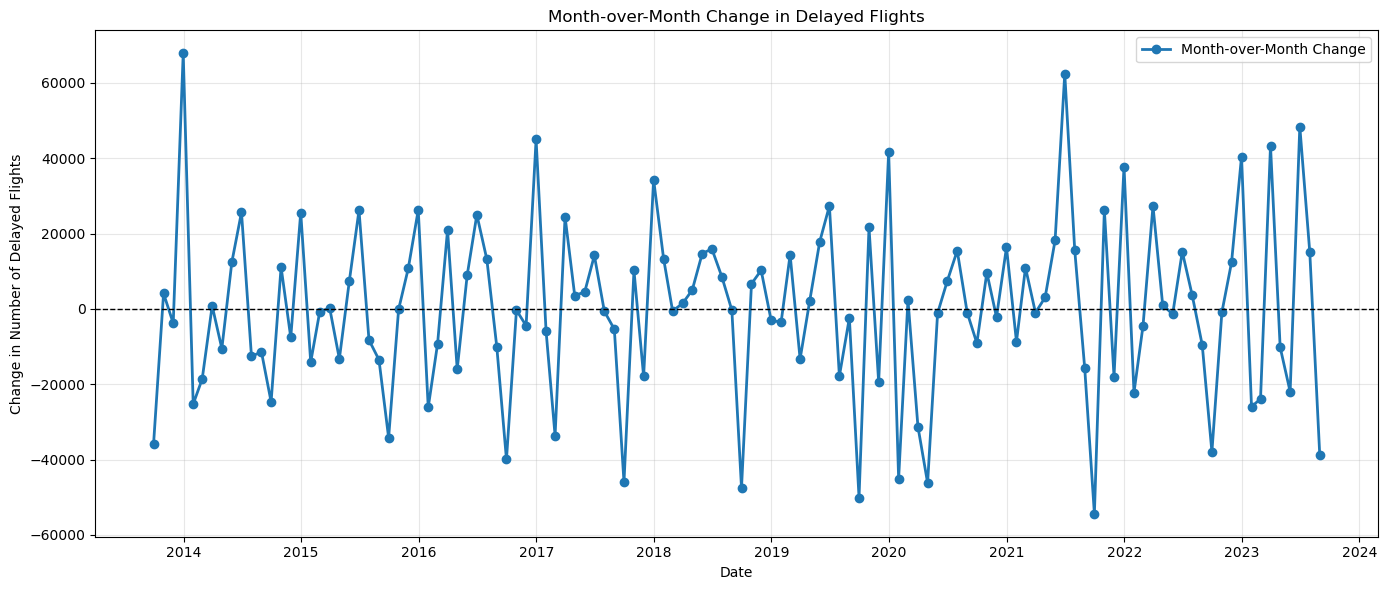

In [248]:
monthly['month_over_month_change'] = np.insert(
    np.diff(monthly['arr_del15']),
    0,
    np.nan
)

monthly

plt.figure(figsize=(14, 6))

plt.plot(
    monthly['date'],
    monthly['month_over_month_change'],
    marker='o',
    linewidth=2,
    label='Month-over-Month Change'
)

# Horizontal line indicating no change
plt.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=1
)

plt.title('Month-over-Month Change in Delayed Flights')
plt.xlabel('Date')
plt.ylabel('Change in Number of Delayed Flights')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

This visualization shows the monthly change in the number of delayed flights relative to the previous month. Positive values indicate an increase in delayed flights, while negative values indicate a decrease.

**Key Observations:**

- The month-over-month changes fluctuate considerably throughout the study period, indicating that flight delays exhibit strong seasonal and operational variability.
- Most monthly changes remain relatively close to zero, suggesting that delay counts are generally stable with moderate month-to-month variation.
- Several large positive and negative spikes are observed, reflecting periods of unusually large increases or decreases in delayed flights.
- The most pronounced fluctuations occur around **2020–2021**, coinciding with the COVID-19 pandemic, which caused substantial disruptions to normal flight operations.
- Following the pandemic, the magnitude of monthly changes remains elevated during the recovery period as air traffic gradually returned to pre-pandemic levels.

Overall, the analysis highlights that while delayed flight counts typically change gradually between months, exceptional events such as the COVID-19 pandemic can produce abrupt shifts in airline delay patterns.

In [ ]:
model_df = df[arr_del15_columns]

X = model_df[['carrier_ct', 'weather_ct', 'nas_ct']].to_numpy()
y = df['arr_del15'].to_numpy()

# Add intercept column
X = np.column_stack([np.ones(len(X)), X])

coefficients, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None) # rcond=None tells how to determine whether a singular value is so small that it should be treated as zero.

coef_df = pd.DataFrame({
    'feature': ['intercept', 'carrier_ct', 'weather_ct', 'nas_ct'],
    'coefficient': coefficients
})

coef_df

,feature,coefficient
0,intercept,-3.191519
1,carrier_ct,2.023784
2,weather_ct,0.773143
3,nas_ct,1.324006


### Linear Regression Model Using NumPy

To understand how different types of delays contribute to the total number of delayed flights (`arr_del15`), we fit a multiple linear regression model using NumPy's `np.linalg.lstsq()` function.

The predictors used in the model are:

- `carrier_ct` – Carrier-related delays
- `weather_ct` – Weather-related delays
- `nas_ct` – National Airspace System (NAS) delays

An intercept term was added manually by including a column of ones in the design matrix.

The fitted regression equation is

$$
\widehat{\text{arr\_del15}}
=
-3.192
+
2.024(\text{carrier\_ct})
+
0.773(\text{weather\_ct})
+
1.324(\text{nas\_ct}).
$$

### Interpretation

- **Intercept (-3.192):** The predicted number of delayed flights when all three predictors are zero. While this value has little practical interpretation, it allows the regression model to fit the data more accurately.
- **Carrier delays (2.024):** Each additional carrier-related delay is associated with approximately **2.02** additional delayed flights, holding the other variables constant. This is the strongest predictor among the variables considered.
- **Weather delays (0.773):** Each additional weather-related delay contributes about **0.77** additional delayed flights on average.
- **NAS delays (1.324):** Each additional NAS-related delay contributes approximately **1.32** additional delayed flights, making it the second most influential predictor.

### Summary

The fitted linear model indicates that **carrier-related delays have the largest impact** on the overall number of delayed flights, followed by **NAS delays**, while **weather delays have the smallest estimated effect** among the three predictors. These coefficients quantify the relative contribution of each delay type and provide a simple predictive model for estimating the total number of delayed flights.